In [3]:
import torch

# Print PyTorch version
print(f"PyTorch version: {torch.__version__}")

# Detect and initialize GPU/CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Running on GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("Running on CPU")

# In PyTorch, `device` handles where tensors and models are placed.
# There isn't a direct equivalent to `strategy.num_replicas_in_sync`
# for single-device operation like in TensorFlow's distribution strategy.
# If you plan to use multiple GPUs, we'd use `torch.nn.DataParallel` or
# `torch.nn.parallel.DistributedDataParallel`, which is a more advanced topic.
print(f"Number of devices (current): 1 (using {device.type}) 🚀")

# There's no direct PyTorch equivalent to Keras version checking or its specific modules.
# We'll use the core PyTorch modules for building neural networks.
from torch import nn
from torch.optim import Adam # A common optimizer, similar to Adam in Keras
from torch.optim.lr_scheduler import ReduceLROnPlateau # Learning rate scheduler
# For early stopping and model checkpointing, we'll implement these directly or use callbacks later.
# There isn't a direct `torch.keras.callbacks` equivalent.

PyTorch version: 2.8.0+cu126
Running on GPU: Tesla T4
Number of devices (current): 1 (using cuda) 🚀


In [4]:
# Instalación de las bibliotecas necesarias
!pip install PyWavelets
!pip install fCWT
!apt-get update
!apt-get install libfftw3-single3 -y

# Importaciones básicas
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import random
import h5py
import pywt
import fcwt
import scipy
from scipy import signal
import gc  # Para liberación explícita de memoria
import time
from datetime import timedelta
from tqdm.notebook import tqdm
from IPython.display import display

# Importaciones para machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Establecer estilo de Matplotlib
plt.style.use('seaborn-v0_8-whitegrid')

Hit:1 https://cli.github.com/packages stable InRelease
Hit:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

In [5]:
# Para montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data Directory: /content/drive/MyDrive/Dataset/Looped
Sample Rate: 25600 Hz
Classification Mode: five_classes
Number of signals (training, testing): (960, 240)
Number of labels (training, testing): (960, 240)
Number of samples per signal: 25600


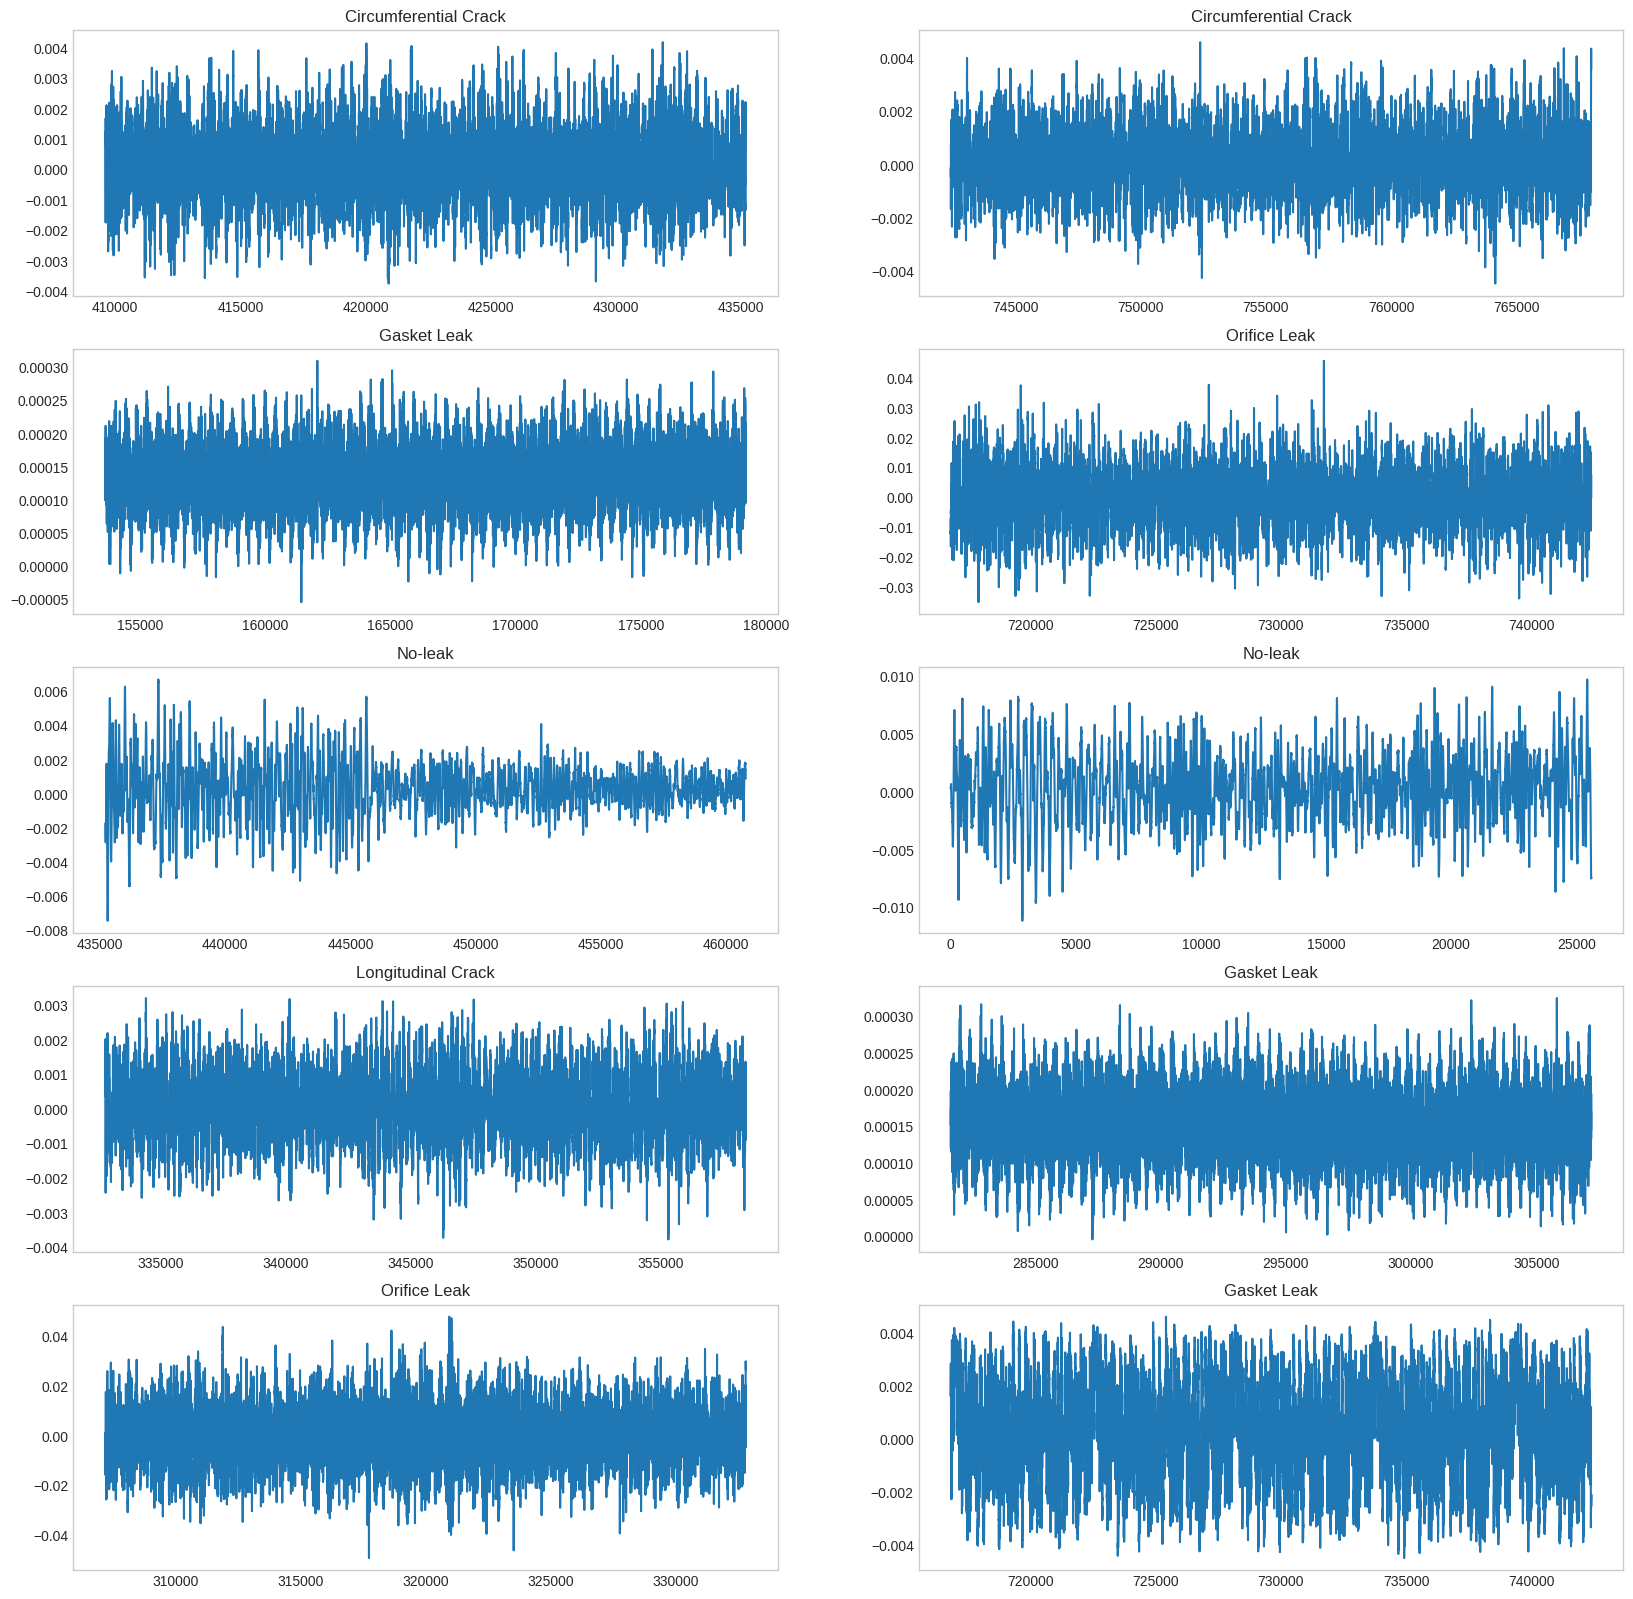

In [6]:
# Definir la ruta de los datos en Google Drive
data_dir = '/content/drive/MyDrive/Dataset/Looped'
original_sr = 25600  # Frecuencia de muestreo original en Hz
signal_sr = 25600  # Frecuencia de muestreo deseada en Hz
downsample_factor = original_sr // signal_sr

# Modo de clasificación: 'five_classes' o 'binary'
classification_mode = 'five_classes'  # Cambiar según necesidad

# Diccionario de etiquetas según el modo de clasificación
if classification_mode == 'five_classes':
    label_codes_dict = {
        'Circumferential Crack': 0,
        'Gasket Leak': 1,
        'Longitudinal Crack': 2,
        'No-leak': 3,
        'Orifice Leak': 4
    }
else:  # binary
    label_codes_dict = {'Leak': 0, 'No-leak': 1}

# Función para eliminar archivos .DS_Store si existen
def remove_DS_store_file(path):
    for ds_name in ['.DS_Store', '.DS_store']:
        ds_store_file_location = os.path.join(path, ds_name)
        if os.path.isfile(ds_store_file_location):
            os.remove(ds_store_file_location)

def load_accelerometer_data(data_dir, sample_rate, downsample_factor, label_codes, mode='five_classes', fraction_to_include=1):
    remove_DS_store_file(data_dir)
    signals = []
    labels = []

    # Para submuestreo en modo binario
    if mode == 'binary':
        # Diccionario para rastrear señales por tipo de fuga
        leak_type_signals = {
            'Circumferential Crack': [],
            'Gasket Leak': [],
            'Longitudinal Crack': [],
            'Orifice Leak': []
        }
        no_leak_signals = []
        sample_labels = []  # Para almacenar etiquetas originales (para estratificación)

    for label in os.listdir(data_dir):
        label_dir = os.path.join(data_dir, label)
        if not os.path.isdir(label_dir):
            print(f"Omitiendo {label_dir} porque no es un directorio")
            continue

        remove_DS_store_file(label_dir)

        for file in os.listdir(label_dir):
            file_path = os.path.join(label_dir, file)
            if not os.path.isfile(file_path):
                continue

            accelerometer_signal_df = pd.read_csv(file_path, index_col=False)
            accelerometer_signal_df = accelerometer_signal_df.iloc[::downsample_factor, :].reset_index(drop=True)
            accelerometer_signal = accelerometer_signal_df['Value'][0:(sample_rate * 30)]

            sample_indexes = np.linspace(0, len(accelerometer_signal) - sample_rate, len(accelerometer_signal) // sample_rate)
            signal_frames_number = fraction_to_include * len(sample_indexes)
            signal_frames_counter = 0

            for signal_frame in sample_indexes:
                accelerometer_signal_frame = accelerometer_signal[int(signal_frame):int(signal_frame + sample_rate)]
                signal_frames_counter += 1

                if signal_frames_counter > signal_frames_number:
                    break

                if len(accelerometer_signal_frame) != sample_rate:
                    continue

                if mode == 'five_classes':
                    signals.append(accelerometer_signal_frame)
                    labels.append(label_codes[label])
                else:  # binary
                    # En vez de añadir directamente, almacenamos por tipo de fuga
                    if label == 'No-leak':
                        no_leak_signals.append(accelerometer_signal_frame)
                        sample_labels.append('No-leak')
                    else:
                        # Almacenar en el diccionario correspondiente
                        leak_type_signals[label].append(accelerometer_signal_frame)
                        sample_labels.append(label)

    # Para modo binario, realizar submuestreo equilibrado
    if mode == 'binary':
        # Número total de muestras No-leak
        total_no_leak = len(no_leak_signals)

        # Calcular cuántas muestras tomar de cada tipo de fuga para balancear con No-leak
        samples_per_leak_type = total_no_leak // 4  # Dividir entre los 4 tipos de fuga

        # Si hay muy pocas muestras de algún tipo, ajustar todas para mantener la proporcionalidad
        min_available = min([len(leak_signals) for leak_signals in leak_type_signals.values()])
        if min_available < samples_per_leak_type:
            samples_per_leak_type = min_available

        # Limitar cada tipo de fuga a la cantidad calculada para balanceo
        balanced_leak_signals = []
        balanced_labels = []
        balanced_stratify = []

        # Añadir todas las muestras No-leak
        for signal in no_leak_signals:
            balanced_leak_signals.append(signal)
            balanced_labels.append(1)  # No-leak
            balanced_stratify.append('No-leak')

        # Añadir cantidades equilibradas de cada tipo de fuga
        for leak_type, leak_signals in leak_type_signals.items():
            # Tomar exactamente samples_per_leak_type muestras de cada tipo de fuga
            for signal in leak_signals[:samples_per_leak_type]:
                balanced_leak_signals.append(signal)
                balanced_labels.append(0)  # Leak
                balanced_stratify.append(leak_type)  # Guardar tipo original para estratificación

        print(f"Balanceo de clases aplicado:")
        print(f"- Muestras No-leak: {total_no_leak}")
        print(f"- Muestras Leak (total): {samples_per_leak_type * 4}")
        print(f"- Muestras por tipo de fuga: {samples_per_leak_type}")

        return balanced_leak_signals, balanced_labels, balanced_stratify

    return signals, labels, None  # None para modo five_classes

# Cargar los datos con submuestreo equilibrado
signals_lst, labels_lst, stratify_labels = load_accelerometer_data(
    data_dir,
    signal_sr,
    downsample_factor,
    label_codes_dict,
    mode=classification_mode,
    fraction_to_include=1
)

# Dividir los datos en conjuntos de entrenamiento y prueba con estratificación
signals_dict = {'training': [], 'testing': []}
labels_dict = {'training': [], 'testing': []}

if stratify_labels:
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'], stratify_train, stratify_test = train_test_split(
        signals_lst,
        labels_lst,
        stratify_labels,
        test_size=0.2,
        random_state=53,
        stratify=stratify_labels
    )
else:
    # Para modo five_classes, usar las etiquetas para estratificar
    signals_dict['training'], signals_dict['testing'], labels_dict['training'], labels_dict['testing'] = train_test_split(
        signals_lst,
        labels_lst,
        test_size=0.2,
        random_state=53,
        stratify=labels_lst  # Estratificar por las etiquetas directamente
    )

# Imprimir información sobre el dataset
print(f'Data Directory: {data_dir}')
print(f'Sample Rate: {signal_sr} Hz')
print(f'Classification Mode: {classification_mode}')
print(f'Number of signals (training, testing): ({len(signals_dict["training"])}, {len(signals_dict["testing"])})')
print(f'Number of labels (training, testing): ({len(labels_dict["training"])}, {len(labels_dict["testing"])})')
print(f'Number of samples per signal: {len(signals_dict["training"][0])}')


# Visualizar algunas señales
plt.figure(figsize=(20, 20))
rows, cols = 5, 2
n = rows * cols
random_index = []

for i in range(n):
    plt.subplot(rows, cols, i + 1)
    random_index.append(np.random.randint(0, len(signals_dict['training'])))
    plt.plot(signals_dict['training'][random_index[i]])

    if classification_mode == 'five_classes':
        label_name = list(label_codes_dict.keys())[list(label_codes_dict.values()).index(labels_dict['training'][random_index[i]])]
    else:
        label_name = 'Leak' if labels_dict['training'][random_index[i]] == 0 else 'No-leak'

    plt.title(label_name)
    plt.grid()
plt.show()

In [7]:
# Modificación de la clase WaveletDenoising para especificar wavelet y nivel directamente
import tqdm
import pywt # Asegúrate de que pywt esté importado si no lo estaba ya
import numpy as np # Asegúrate de que numpy esté importado si no lo estaba ya

class WaveletDenoising:
    """Clase para denoising con wavelets con wavelet y nivel específicos."""

    def __init__(self, normalize=True, wavelet='db4', level=3, thr_mode='soft', method="universal"):
        """
        Inicializa el denoiser con parámetros específicos.

        Args:
            normalize: Si es True, normaliza la señal antes del denoising.
            wavelet: Wavelet a utilizar.
            level: Nivel de descomposición wavelet.
            thr_mode: Modo de umbralización ('soft' o 'hard').
            method: Método de umbralización ("universal" o "level_dependent").
        """
        self.normalize = normalize
        self.wavelet = wavelet
        self.level = level
        self.thr_mode = thr_mode
        self.method = method

    def fit(self, data):
        """Aplica el denoising a los datos de entrada."""
        # Convertir a array numpy
        data = np.asarray(data)

        # Normalizar si es necesario
        if self.normalize:
            data = (data - np.mean(data)) / (np.std(data) if np.std(data) != 0 else 1.0)

        # Descomponer con wavelet
        coeffs = pywt.wavedec(data, self.wavelet, level=self.level)

        # Umbral
        if self.method == "universal":
            sigma = self._estimate_sigma(coeffs[-1])
            threshold = sigma * np.sqrt(2 * np.log(len(data)))
        else:
            threshold = self._estimate_level_dependent_threshold(coeffs)

        # Aplicar umbral
        new_coeffs = []
        new_coeffs.append(coeffs[0])  # Aproximación
        for i in range(1, len(coeffs)):
            if self.thr_mode == 'soft':
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='soft'))
            else:
                new_coeffs.append(pywt.threshold(coeffs[i], threshold, mode='hard'))

        # Reconstruir
        return pywt.waverec(new_coeffs, self.wavelet)

    def _estimate_sigma(self, detail_coeffs):
        """Estima la desviación estándar del ruido."""
        return np.median(np.abs(detail_coeffs)) / 0.6745

    def _estimate_level_dependent_threshold(self, coeffs):
        """Estima umbrales dependientes del nivel."""
        return np.std(coeffs[-1]) * 3.0

def apply_wavelet_denoising(signals_dict, wavelet, level):
    """
    Aplica denoising wavelet con una wavelet y nivel específicos.

    Args:
        signals_dict: Diccionario con señales de entrenamiento y prueba
        wavelet: Nombre de la wavelet a utilizar
        level: Nivel de descomposición

    Returns:
        wavelet_denoised_signals: Diccionario con señales procesadas
    """
    # Crear objeto WaveletDenoising con los parámetros especificados
    wd = WaveletDenoising(
        normalize=True,
        wavelet=wavelet,
        level=level,
        thr_mode='soft',
        method="universal"
    )

    # Crear diccionario para señales procesadas
    wavelet_denoised_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal_element in tqdm.tqdm(signals_subset, desc=f"Aplicando {wavelet} nivel {level} a {key}"):
            # Denoising de la señal
            try:
                denoised_signal = wd.fit(signal_element)
                wavelet_denoised_signals[key].append(denoised_signal)
            except Exception as e:
                print(f"Error al procesar señal con {wavelet} nivel {level}: {str(e)}")
                # En caso de error, usar la señal original
                wavelet_denoised_signals[key].append(signal_element)

    return wavelet_denoised_signals

wavelet_denoised_signals_dict=apply_wavelet_denoising(signals_dict, "sym3", 4)

# Función para normalizar señales
def normalize_signals(signals_dict):
    """
    Normaliza cada señal del diccionario a un rango de 0 a 1.

    Args:
        signals_dict: Diccionario con señales a normalizar.

    Returns:
        normalized_signals: Diccionario con señales normalizadas.
    """
    normalized_signals = {'training': [], 'testing': []}

    for key, signals_subset in signals_dict.items():
        for signal in tqdm.tqdm(signals_subset, desc=f"Normalizando {key} signals"):
            min_val = np.min(signal)
            max_val = np.max(signal)

            if max_val > min_val:
                normalized_signal = (signal - min_val) / (max_val - min_val)
            else:
                normalized_signal = np.ones_like(signal) * 0.5

            normalized_signals[key].append(normalized_signal)

    return normalized_signals

wavelet_denoised_signals_dict=normalize_signals(wavelet_denoised_signals_dict)
#del signals_dict # No es necesario cambiar, solo si se quiere liberar memoria
gc.collect() # No es necesario cambiar, solo si se quiere liberar memoria

Normalizando testing signals: 100%|██████████| 240/240 [00:00<00:00, 5885.19it/s]


27644

In [8]:
# Función para aplicar padding a una señal según el modo especificado
def pad_signal(signal, pad_width, mode='symmetric'):
    """
    Aplica padding a una señal utilizando PyWavelets pywt.pad.

    Args:
        signal: Señal a la que aplicar padding
        pad_width: Ancho del padding (int o tuple de la forma (left_pad, right_pad))
        mode: Modo de padding ('zero', 'constant', 'symmetric', 'reflect', etc.)
              o 'none' para no aplicar padding

    Returns:
        Señal con padding aplicado o la señal original si mode='none'
    """
    # Convertir a array numpy si no lo es
    signal = np.array(signal)

    # Si el modo es 'none', devolver la señal original sin padding
    if mode == 'none':
        return signal

    # Usar pywt.pad para aplicar padding consistente con PyWavelets
    try:
        padded_signal = pywt.pad(signal, pad_width, mode)
    except Exception as e:
        print(f"Error al aplicar padding con modo {mode}: {e}")
        print("Usando modo 'symmetric' como alternativa")
        padded_signal = pywt.pad(signal, pad_width, 'symmetric')

    return padded_signal

def calculate_cwt_pywt(signal, scales, wavelet='morl', mode='symmetric'):
    """
    Calcula la CWT utilizando PyWavelets con el modo de padding especificado.

    Args:
        signal: Señal a transformar
        scales: Escalas para el cálculo de la CWT
        wavelet: Wavelet a utilizar
        mode: Modo de padding

    Returns:
        Coeficientes CWT, frecuencias
    """
    # Calcular la CWT
    coeffs, freqs = pywt.cwt(signal, scales, wavelet, mode=mode)

    return coeffs, freqs

def calculate_cwt_fcwt(signal, fs=25600, f0=1.0, f1=None, fn=20, sigma=6.0,
                         mode='symmetric'):
    """
    Calcula la CWT utilizando fCWT con el modo de padding especificado.

    Args:
        signal: Señal a transformar
        fs: Frecuencia de muestreo
        f0: Frecuencia mínima
        f1: Frecuencia máxima
        fn: Número de frecuencias
        sigma: Parámetro sigma de la wavelet Morlet
        mode: Modo de padding ('zero', 'constant', 'symmetric', 'reflect', etc.)
              o 'none' para no aplicar padding

    Returns:
        Coeficientes CWT, frecuencias, escalas
    """
    # Inicializar el atributo estático si no existe
    if not hasattr(calculate_cwt_fcwt, 'info_printed'):
        calculate_cwt_fcwt.info_printed = False

    try:
        import fcwt
    except ImportError:
        print("Error: fCWT no está instalado correctamente.")
        return None, None, None

    # Determinar la frecuencia máxima si no se especifica
    if f1 is None:
        f1 = fs / 2

    original_length = len(signal)

    if mode == 'none':
        # Para el modo 'none', no aplicamos padding pero verificamos si la longitud es potencia de 2
        # (requisito para algunas implementaciones de CWT basadas en FFT)
        is_power_of_two = (original_length & (original_length - 1)) == 0
        if not is_power_of_two:
            print(f"Advertencia: La longitud de la señal ({original_length}) no es potencia de 2. "
                  f"Algunos algoritmos de CWT pueden ser menos eficientes.")
        # Usar la señal original sin padding
        padded_signal = np.array(signal, dtype=np.float32)
    else:
        # Aplicar padding hasta la potencia de dos inmediata superior
        # Comprobar si ya es potencia de dos
        is_power_of_two = (original_length & (original_length - 1)) == 0

        if is_power_of_two:
            # Si ya es potencia de dos, duplicar el tamaño
            target_length = original_length * 2
        else:
            # Calcular la próxima potencia de dos
            target_length = 2 ** np.ceil(np.log2(original_length)).astype(int)

        # Calcular el padding total necesario
        total_padding = target_length - original_length

        # Distribuir el padding equitativamente en ambos lados
        pad_left = int(total_padding // 2)
        pad_right = int(total_padding - pad_left)

        # Aplicar el padding
        if pad_left > 0 or pad_right > 0:
            padded_signal = pad_signal(signal, (pad_left, pad_right), mode=mode)
        else:
            padded_signal = np.array(signal)

        # Convertir a float32 para compatibilidad con fCWT
        padded_signal = np.array(padded_signal, dtype=np.float32)

    # Inicializar wavelet Morlet
    morlet = fcwt.Morlet(sigma)

    # Configurar escalas logarítmicas
    scale_type = fcwt.FCWT_LOGSCALES
    scales_obj = fcwt.Scales(morlet, scale_type, fs, f0, f1, fn)

    # Obtener arrays de escalas y frecuencias
    scales = np.zeros(fn, dtype=np.float32)
    freqs = np.zeros(fn, dtype=np.float32)
    scales_obj.getScales(scales)
    scales_obj.getFrequencies(freqs)

    # Solo mostrar información sobre escalas la primera vez que se llama a la función
    if not calculate_cwt_fcwt.info_printed:
        # Tomamos la razón promedio entre escalas consecutivas
        scale_ratios = scales[1:] / scales[:-1]
        avg_ratio = np.mean(scale_ratios)
        voices_per_octave = np.log(2) / np.log(avg_ratio)

        print(f"Número de voces por octava (Q): {voices_per_octave:.2f}")
        print(f"Escalas generadas: {scales}")

        # Verificamos si la distribución de escalas es uniforme en escala logarítmica
        std_ratio = np.std(scale_ratios)
        print(f"Desviación estándar de ratios entre escalas: {std_ratio:.6f}")
        if std_ratio < 1e-5:
            print("Las escalas siguen una distribución logarítmica uniforme")
        # Marcar que ya imprimimos la información
        calculate_cwt_fcwt.info_printed = True

    nthreads=1
    use_optimization_plan = False
    use_normalization = True

    # Calcular la CWT
    fcwt_obj = fcwt.FCWT(morlet, nthreads, use_optimization_plan, use_normalization)
    cwt_output = np.zeros((fn, len(padded_signal)), dtype=np.complex64)
    fcwt_obj.cwt(padded_signal, scales_obj, cwt_output)

    # Si se usó 'none' y los resultados deben ser recortados al tamaño original
    # (esto depende de la implementación específica de CWT y lo que se desea)
    # if mode == 'none' and len(cwt_output[0]) != original_length:
    #     # Recortar para mantener el tamaño original de la señal
    #     # Nota: Esto es opcional y depende de los requisitos específicos
    #     cwt_output = cwt_output[:, :original_length]
    #     print(f"La CWT sin padding fue recortada a la longitud original de la señal: {original_length}")

    return cwt_output, freqs, scales

In [9]:
# Función principal para calcular escalogramas con diferentes modos de padding
def calculate_scalograms_with_padding_modes(signals_dict, labels_dict, modes, fs=25600, library='fcwt'):
    """
    Calcula escalogramas para un conjunto de señales utilizando diferentes modos de padding.

    Args:
        signals_dict: Diccionario con señales {'training': [...], 'testing': [...]}
        labels_dict: Diccionario con etiquetas {'training': [...], 'testing': [...]}
        modes: Lista de modos de padding a utilizar
        fs: Frecuencia de muestreo
        library: Biblioteca a utilizar ('pywt' o 'fcwt')

    Returns:
        Dictionary con escalogramas para cada señal y modo
    """
    results = {'training': {}, 'testing': {}}

    # Parámetros para ambas bibliotecas
    if library == 'pywt':
        # Para PyWavelets
        # Definir escalas logarítmicas (similar a fCWT)
        num_scales = 20
        scales = np.logspace(0.5, 3, num_scales)

    elif library == 'fcwt':
        # Para fCWT
        f0 = 1.0
        f1 = fs / 2
        fn = 50
        sigma = 6.0

    for dataset_key in ['training', 'testing']:
        signals = signals_dict[dataset_key]
        labels = labels_dict[dataset_key]

        print(f"\nProcesando señales de {dataset_key}...")

        # Para cada señal
        for i, signal in enumerate(tqdm.tqdm(signals, desc=f"Procesando señales de {dataset_key}")):
            if i not in results[dataset_key]:
                results[dataset_key][i] = {}

            # Para cada modo de padding
            for mode in modes:
                try:
                    if library == 'pywt':
                        # Usar PyWavelets
                        coeffs, freqs = calculate_cwt_pywt(signal, scales, wavelet='morl', mode=mode)
                        scalogram = np.abs(coeffs)**2

                        results[dataset_key][i][mode] = {
                            'scalogram': scalogram,
                            'freqs': freqs,
                            'scales': scales,
                            'label': labels[i]  # Guardar también la etiqueta
                        }

                    elif library == 'fcwt':
                        # Usar fCWT
                        coeffs, freqs, scales = calculate_cwt_fcwt(signal, fs=fs, f0=f0, f1=f1, fn=fn,
                                                                    sigma=sigma, mode=mode)
                        if coeffs is not None:
                            scalogram = np.abs(coeffs)**2
                            results[dataset_key][i][mode] = {
                                'scalogram': scalogram,
                                'freqs': freqs,
                                'scales': scales,
                                'label': labels[i]  # Guardar también la etiqueta
                            }
                except Exception as e:
                    print(f"Error calculando escalograma para señal {i}, modo {mode}: {e}")
                    continue

    return results

# Lista de modos de padding disponibles en PyWavelets
padding_modes = ['symmetric', 'reflect', 'periodic', 'constant', 'zero', 'smooth', 'none']
selected_padding_mode = ['periodic']


# Calcular escalogramas con diferentes modos de padding usando fCWT
print("Calculando escalogramas con fCWT...")
fcwt_scalograms = calculate_scalograms_with_padding_modes(
    wavelet_denoised_signals_dict,
    labels_dict,
    selected_padding_mode,
    fs=25600,
    library='fcwt'
)
# Normalizar, aplicar logaritmo, y volver a normalizar los escalogramas
print("Normalizando y aplicando transformación logarítmica a los escalogramas...")

# Función para normalizar un array entre 0 y 1
def normalize(arr):
    arr_min = arr.min()
    arr_max = arr.max()
    if arr_max > arr_min:  # Evitar división por cero
        return (arr - arr_min) / (arr_max - arr_min)
    else:
        return arr

# Procesar todos los escalogramas
for dataset_key in ['training', 'testing']:
    for i in tqdm.tqdm(fcwt_scalograms[dataset_key].keys(), desc=f"Procesando conjunto {dataset_key}"):
        for mode in fcwt_scalograms[dataset_key][i].keys():
            # Obtener el escalograma
            scalogram = fcwt_scalograms[dataset_key][i][mode]['scalogram']
            # 1. Normalizar el escalograma original
            scalogram_norm = normalize(scalogram)

            # 2. Aplicar transformación logarítmica (sumar pequeña constante para evitar log(0))
            scalogram_log = np.log(scalogram_norm + 1e-6)

            # 3. Volver a normalizar
            scalogram_final = normalize(scalogram_log)

            # Reemplazar el escalograma original con el procesado
            # Esto asegura que el código posterior siga funcionando sin cambios
            fcwt_scalograms[dataset_key][i][mode]['scalogram'] = scalogram_final



# Mostrar información sobre los escalogramas procesados
for dataset_key in ['training', 'testing']:
    # Tomar la primera clave disponible
    first_key = list(fcwt_scalograms[dataset_key].keys())[0]
    first_mode = list(fcwt_scalograms[dataset_key][first_key].keys())[0]

    # Obtener forma del escalograma procesado
    sample_shape = fcwt_scalograms[dataset_key][first_key][first_mode]['scalogram'].shape

    print(f"\nForma de los escalogramas procesados en {dataset_key}: {sample_shape}")

    # Obtener estadísticas básicas
    sample_scalogram = fcwt_scalograms[dataset_key][first_key][first_mode]['scalogram']
    print(f"Valor mínimo: {sample_scalogram.min():.6f}")
    print(f"Valor máximo: {sample_scalogram.max():.6f}")
    print(f"Media: {sample_scalogram.mean():.6f}")

Calculando escalogramas con fCWT...

Procesando señales de training...


Procesando señales de training:   1%|          | 6/960 [00:00<00:17, 54.38it/s]

Número de voces por octava (Q): 3.59
Escalas generadas: [2.0000000e+00 2.4257755e+00 2.9421935e+00 3.5685503e+00 4.3282514e+00
 5.2496829e+00 6.3672757e+00 7.7227917e+00 9.3668785e+00 1.1360971e+01
 1.3779585e+01 1.6713087e+01 2.0271099e+01 2.4586571e+01 2.9820755e+01
 3.6169220e+01 4.3869209e+01 5.3208431e+01 6.4535843e+01 7.8274742e+01
 9.4938484e+01 1.1514970e+02 1.3966367e+02 1.6939638e+02 2.0545874e+02
 2.4919843e+02 3.0224976e+02 3.6659506e+02 4.4463870e+02 5.3929651e+02
 6.5410626e+02 7.9335754e+02 9.6225372e+02 1.1671058e+03 1.4155686e+03
 1.7169260e+03 2.0824373e+03 2.5257629e+03 3.0634673e+03 3.7156426e+03
 4.5066577e+03 5.4660708e+03 6.6297266e+03 8.0411147e+03 9.7529707e+03
 1.1829260e+04 1.4347566e+04 1.7401988e+04 2.1106648e+04 2.5599998e+04]
Desviación estándar de ratios entre escalas: 0.000000
Las escalas siguen una distribución logarítmica uniforme


Procesando señales de training: 100%|██████████| 960/960 [00:19<00:00, 48.07it/s]



Procesando señales de testing...


Procesando señales de testing: 100%|██████████| 240/240 [00:05<00:00, 44.67it/s]


Normalizando y aplicando transformación logarítmica a los escalogramas...


Procesando conjunto testing: 100%|██████████| 240/240 [00:02<00:00, 86.56it/s]


Forma de los escalogramas procesados en training: (50, 32768)
Valor mínimo: 0.000000
Valor máximo: 1.000000
Media: 0.445438

Forma de los escalogramas procesados en testing: (50, 32768)
Valor mínimo: 0.000000
Valor máximo: 1.000000
Media: 0.442191


## Preentrenado


In [10]:
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
import gc
from tqdm import tqdm
import numpy as np
# Necesitas scipy o skimage para redimensionar si no quieres recortar
# from scipy.ndimage import zoom

# --- PARÁMETRO DE REDUCCIÓN ---
TARGET_TIME_POINTS = 2048 # Reducir la dimensión de tiempo a un tamaño manejable (ej. 256)

# --- 1. FUNCIÓN DE EXTRACCIÓN MODIFICADA (Añade Recorte de Tiempo) ---

def extract_scalograms_for_training(fcwt_scalograms, mode='periodic', target_time_points=TARGET_TIME_POINTS):
    """
    Extrae escalogramas y etiquetas, AÑADIENDO UN PASO DE RECORTE
    para reducir el consumo de RAM.
    """
    print(f"Extrayendo y REDIMENSIONANDO escalogramas a {fcwt_scalograms['training'][0][mode]['scalogram'].shape[0]}x{target_time_points}...")

    # Función auxiliar para recortar o redimensionar
    def process_scalogram(scalogram):
        # 1. Recorte del eje de tiempo (asumiendo que el eje es (Frecuencias, Tiempo))
        original_length = scalogram.shape[1]

        if original_length > target_time_points:
            # Calcular dónde empezar para centrar el recorte
            start = (original_length - target_time_points) // 2
            end = start + target_time_points
            return scalogram[:, start:end]
        elif original_length < target_time_points:
            # Rellenar con ceros si es más corto (aunque es poco probable aquí)
            pad_needed = target_time_points - original_length
            pad_left = pad_needed // 2
            pad_right = pad_needed - pad_left
            return np.pad(scalogram, ((0, 0), (pad_left, pad_right)), mode='constant')
        else:
            return scalogram

    # Extracción y Recorte para Training
    train_scalograms = []
    train_labels = []
    for idx in tqdm(fcwt_scalograms['training'].keys(), desc="Procesando conjunto training"):
        if mode in fcwt_scalograms['training'][idx]:
            scalogram = fcwt_scalograms['training'][idx][mode]['scalogram']
            train_scalograms.append(process_scalogram(scalogram))
            train_labels.append(fcwt_scalograms['training'][idx][mode]['label'])

    # Extracción y Recorte para Testing
    test_scalograms = []
    test_labels = []
    for idx in tqdm(fcwt_scalograms['testing'].keys(), desc="Procesando conjunto testing"):
        if mode in fcwt_scalograms['testing'][idx]:
            scalogram = fcwt_scalograms['testing'][idx][mode]['scalogram']
            test_scalograms.append(process_scalogram(scalogram))
            test_labels.append(fcwt_scalograms['testing'][idx][mode]['label'])

    # Convertir a arrays numpy (¡AHORA MUCHO MÁS PEQUEÑOS!)
    train_array = np.array(train_scalograms, dtype=np.float32)
    train_labels_array = np.array(train_labels, dtype=np.int32)
    test_array = np.array(test_scalograms, dtype=np.float32)
    test_labels_array = np.array(test_labels, dtype=np.int32)

    # Liberar listas intermedias
    del train_scalograms, train_labels, test_scalograms, test_labels

    print(f"- Escalogramas de entrenamiento final: {train_array.shape}")
    print(f"- Escalogramas de prueba final: {test_array.shape}")

    return train_array, train_labels_array, test_array, test_labels_array


# --- 2. EJECUCIÓN DE EXTRACCIÓN Y LIMPIEZA DE RAM ---
mode = 'periodic'
print("Ejecutando extracción de arrays de NumPy con Recorte de Tiempo...")

# Usamos TARGET_TIME_POINTS para la reducción.
train_array, train_labels_array, test_array, test_labels_array = extract_scalograms_for_training(
    fcwt_scalograms, mode=mode, target_time_points=TARGET_TIME_POINTS
)

# Liberar el diccionario fcwt_scalograms que agota la memoria
print("Liberando fcwt_scalograms de la RAM...")
#del fcwt_scalograms
gc.collect()

# --- 3. CLASE Custom Dataset (Sin Cambios, ya que la reducción se hizo antes) ---

class ScalogramDataset(Dataset):
    """
    Dataset personalizado que maneja los escalogramas (NumPy arrays) ya reducidos y
    los convierte a tensores de 3 canales (ViT ready) al ser solicitados.
    """
    def __init__(self, data_array, label_array, transform=None):
        self.data = data_array
        self.labels = label_array
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        scalogram = self.data[idx]
        label = self.labels[idx]

        # Convertir a tensor de PyTorch (float32)
        image = torch.from_numpy(scalogram).float()

        # Añadir canal (1, H, W)
        image = image.unsqueeze(0)

        # ADAPTACIÓN CRUCIAL PARA ViT: Replicar a 3 canales (3, H, W)
        image = image.repeat(3, 1, 1)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

# --- 4. División Entrenamiento/Validación y Creación de Datasets ---

print("\nCreando splits de entrenamiento/validación...")
x_train_np, x_val_np, y_train_np, y_val_np = train_test_split(
    train_array,
    train_labels_array,
    test_size=0.2,
    stratify=train_labels_array,
    random_state=42
)

# Liberar el array original completo (ya reducido)
del train_array
del train_labels_array
gc.collect()

# Crear instancias de Dataset
train_dataset = ScalogramDataset(x_train_np, y_train_np)
val_dataset = ScalogramDataset(x_val_np, y_val_np)
test_dataset = ScalogramDataset(test_array, test_labels_array)


# --- 5. Creación de DataLoaders ---

BATCH_SIZE = 32 # Ajusta esto si la VRAM de la GPU es pequeña

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# --- 6. Impresión de Información y Limpieza Final ---

sample_batch_x, _ = next(iter(train_loader))

num_classes = len(label_codes_dict)

print("\n✅ Dataset y DataLoaders creados correctamente.")
print(f"Muestras de entrenamiento: {len(train_dataset)}")
print(f"Forma final de entrada para ViT: {sample_batch_x.shape} (C={sample_batch_x.shape[1]}, H={sample_batch_x.shape[2]}, W={sample_batch_x.shape[3]})")

# Limpieza final de los arrays NumPy temporales y de prueba
del x_train_np, x_val_np, y_train_np, y_val_np, test_array, test_labels_array
gc.collect()

# Almacenar los DataLoaders para la siguiente celda
dataset_info = {
    'train_loader': train_loader,
    'val_loader': val_loader,
    'test_loader': test_loader,
    'num_classes': num_classes,
    'label_codes_dict': label_codes_dict
}

Ejecutando extracción de arrays de NumPy con Recorte de Tiempo...
Extrayendo y REDIMENSIONANDO escalogramas a 50x2048...


Procesando conjunto testing: 100%|██████████| 240/240 [00:00<00:00, 468855.59it/s]

- Escalogramas de entrenamiento final: (960, 50, 2048)
- Escalogramas de prueba final: (240, 50, 2048)
Liberando fcwt_scalograms de la RAM...



Creando splits de entrenamiento/validación...

✅ Dataset y DataLoaders creados correctamente.
Muestras de entrenamiento: 768
Forma final de entrada para ViT: torch.Size([32, 3, 50, 2048]) (C=3, H=50, W=2048)


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
# Asegúrate de tener instalada la librería timm: !pip install timm
from timm.models.vision_transformer import vit_base_patch16_224

# --- PARÁMETROS DEL MODELO ---
# Usamos las dimensiones del escalograma después de la reducción
INPUT_CHANNELS = 3
INPUT_HEIGHT = 50  # Frecuencias
INPUT_WIDTH = 2048  # Tiempo (Recortado)

class LogPSViT(nn.Module):
    """
    Clase para construir un Vision Transformer (ViT) pre-entrenado
    adaptado para la clasificación de escalogramas.
    """
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary

        # Cargar un modelo ViT pre-entrenado
        # Se usa 'vit_base_patch16_224' con los pesos pre-entrenados de ImageNet
        self.vit = vit_base_patch16_224(pretrained=True)

        # 1. AJUSTAR LA CAPA DE EMBEDDING DE PARCHES
        # El tamaño de entrada (50x256) no es estándar. Reemplazamos el PatchEmbed
        # por una convolución que maneje este tamaño, pero manteniendo el mismo
        # tamaño de parche (16x16) y dimensión de salida (768).
        self.vit.patch_embed = nn.Conv2d(
            in_channels=input_shape[0], # 3 canales
            out_channels=768,
            kernel_size=(16, 16),
            stride=(16, 16),
            padding='valid'
        )

        # 2. CALCULAR LAS NUEVAS DIMENSIONES DE LOS PARCHES
        # Input: (50, 256). Patch: 16x16. Stride: 16x16.
        # Fórmula: O = floor((I - K) / S) + 1
        H = input_shape[1]
        W = input_shape[2]
        K_H, K_W = self.vit.patch_embed.kernel_size
        S_H, S_W = self.vit.patch_embed.stride

        # Cálculo para la Altura (Frecuencias): 50x16 -> (50-16)/16 + 1 = 34/16 + 1 = 2 + 1 = 3
        num_patches_h = (H - K_H) // S_H + 1
        # Cálculo para el Ancho (Tiempo): 256x16 -> (256-16)/16 + 1 = 240/16 + 1 = 15 + 1 = 16
        num_patches_w = (W - K_W) // S_W + 1

        # 3. AJUSTAR EL EMBEDDING DE POSICIÓN (pos_embed)
        # El tamaño debe ser (1, num_patches + 1, dim_embedding)
        # Donde +1 es para el token [CLS]
        self.vit.pos_embed = nn.Parameter(
            # Recalculamos el tamaño basado en el nuevo número total de parches
            torch.zeros(1, num_patches_h * num_patches_w + 1, self.vit.pos_embed.shape[2])
        )

        # 4. REEMPLAZAR LA CABEZA DE CLASIFICACIÓN
        in_features = self.vit.head.in_features # Generalmente 768

        if self.is_binary:
            # Una sola salida, sin activación final aquí (usaremos BCEWithLogitsLoss o similar)
            self.vit.head = nn.Linear(in_features, 1)
        else:
            # Salida con el número de clases
            self.vit.head = nn.Linear(in_features, num_classes)

    def forward(self, x):
        x = self.vit(x)
        # Nota: La activación sigmoid/softmax generalmente se aplica en la función de pérdida
        # o después. Lo mantengo aquí por coherencia con el código original,
        # pero para el entrenamiento se recomienda devolver los logits puros.
        if self.is_binary:
            # Usar sigmoid para convertir logits a probabilidad [0, 1] en clasificación binaria
            return torch.sigmoid(x)
        else:
            # Devolver los logits para CrossEntropyLoss en multiclasificación
            return x

# --- EJECUCIÓN Y PRUEBA DEL MODELO ---

# Obtener parámetros del dataset_info de la celda anterior
NUM_CLASSES = dataset_info['num_classes']
IS_BINARY = (NUM_CLASSES == 2)

# Definir la forma de entrada real
MODEL_INPUT_SHAPE = (INPUT_CHANNELS, INPUT_HEIGHT, INPUT_WIDTH) # (3, 50, 256)

# Crear el modelo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_vit = LogPSViT(
    input_shape=MODEL_INPUT_SHAPE,
    num_classes=NUM_CLASSES,
    is_binary=IS_BINARY
).to(device)

print(f"✅ Modelo ViT cargado en '{device}' y adaptado.")
print(f"Modo de clasificación: {'Binario' if IS_BINARY else 'Multiclase'}")
print(f"Forma de entrada esperada: {MODEL_INPUT_SHAPE}")

# Verificación de la forma del pos_embed
num_total_patches = modelo_vit.vit.pos_embed.shape[1] - 1
print(f"Parches de entrada calculados: {num_total_patches}")
print(f"Nueva forma del pos_embed: {modelo_vit.vit.pos_embed.shape}")
print(f"Forma de la capa final (Head): {modelo_vit.vit.head}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


✅ Modelo ViT cargado en 'cuda' y adaptado.
Modo de clasificación: Multiclase
Forma de entrada esperada: (3, 50, 2048)
Parches de entrada calculados: 384
Nueva forma del pos_embed: torch.Size([1, 385, 768])
Forma de la capa final (Head): Linear(in_features=768, out_features=5, bias=True)


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
import torch.nn.init as init
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# --- PARÁMETROS DE CONFIGURACIÓN DE LAS CELDAS ANTERIORES ---
# Estas variables se inicializan a partir de 'dataset_info'
train_loader = dataset_info['train_loader']
val_loader = dataset_info['val_loader']
test_loader = dataset_info['test_loader']
NUM_CLASSES = dataset_info['num_classes']
IS_BINARY = (NUM_CLASSES == 2)
# ⚠️ ADVERTENCIA: Se ha mantenido en 256 para evitar fallo de RAM.
INPUT_SHAPE = (3, 50, 2048)
classification_mode = 'binary' if IS_BINARY else f'{NUM_CLASSES}_classes'
label_codes_dict = dataset_info.get('label_codes_dict', {0: 'Clase 0', 1: 'Clase 1', 2: 'Clase 2', 3: 'Clase 3', 4: 'Clase 4'})


# ----------------------------------------------------------------------------------
#  CLASE DEL MODELO (CORRECCIONES FINALES PARA VIABILIDAD)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        # ⚠️ Se usa el ViT base de timm
        self.vit = vit_base_patch16_224(pretrained=True)
        self.embed_dim = self.vit.embed_dim # 768

        # 1. Adaptar Patch Embedding
        self.patch_embed = nn.Conv2d(
            in_channels=input_shape[0], out_channels=self.embed_dim, kernel_size=(16, 16), stride=(16, 16), padding='valid'
        )

        # 2. Recalcular y Reconstruir Positional Embedding
        H, W = input_shape[1], input_shape[2]
        # Cálculo dinámico basado en H=50 (resulta en 3 parches) y W (resulta en W/16 parches)
        num_patches_h = (H - 16) // 16 + 1
        num_patches_w = (W - 16) // 16 + 1
        num_patches_new = num_patches_h * num_patches_w

        # Clonar CLS Token
        self.cls_token = nn.Parameter(self.vit.cls_token.data.clone())

        # Crear y inicializar nuevo pos_embed
        new_pos_embed = nn.Parameter(torch.zeros(1, num_patches_new + 1, self.embed_dim))
        init.trunc_normal_(new_pos_embed, std=.02)
        self.pos_embed = new_pos_embed

        # 3. Adaptar Classification Head
        in_features = self.vit.head.in_features
        # 💧 Añadir Dropout para regularización antes del Head
        self.dropout = nn.Dropout(p=0.2)
        if self.is_binary:
            self.head = nn.Linear(in_features, 1)
        else:
            self.head = nn.Linear(in_features, num_classes)

        # 4. Asignaciones y Correcciones de Atributos (SOLUCIÓN Attribute Error)
        self.vit.patch_embed = self.patch_embed
        self.vit.cls_token = self.cls_token
        self.vit.pos_embed = self.pos_embed
        self.vit.head = self.head

        # 🐛 CORRECCIÓN DE ATTRIBUTEERROR: Inicializar pre_logits si no existe
        if not hasattr(self.vit, 'pre_logits'):
             self.vit.pre_logits = nn.Identity()

        # 5. CONGELAR PESOS
        for param in self.vit.parameters():
            param.requires_grad = False

        # Descongelar capas adaptadas
        self.patch_embed.requires_grad_(True)
        self.pos_embed.requires_grad_(True)
        self.head.requires_grad_(True)


    def forward(self, x):
        # Implementación manual del forward (SOLUCIÓN RuntimeError 3D/4D)

        # 1. Patch Embedding (4D -> 3D)
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)

        # 2. Add CLS Token (3D)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)

        # 3. Add Positional Embedding (3D + 3D)
        x = x + self.vit.pos_embed

        # 4. Transformer Blocks
        x = self.vit.pos_drop(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)

        # 5. Classification
        x = self.vit.pre_logits(x[:, 0])
        x = self.vit.head(x)

        if self.is_binary:
            return torch.sigmoid(x).squeeze(1)
        else:
            return x

# ----------------------------------------------------------------------------------
#  CONFIGURACIÓN, ENTRENAMIENTO Y EVALUACIÓN
# ----------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
epochs = 100
early_stop_patience = 20
model_save_path = f'/content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_{classification_mode}.pt'

model = LogPSViT(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, is_binary=IS_BINARY)
model.to(device)

criterion = nn.BCELoss() if IS_BINARY else nn.CrossEntropyLoss()
learning_rate = 0.0001

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate, weight_decay=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5, min_lr=1e-6)

# Normalización estándar de ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []}
best_val_loss = float('inf')
epochs_no_improve = 0


print("\nComenzando el entrenamiento del modelo Vision Transformer...")

# --- BUCLE PRINCIPAL DE ENTRENAMIENTO ---
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss, train_correct_preds, train_total_samples = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)

        if IS_BINARY: labels_for_loss = labels.float()
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        if IS_BINARY: preds = (outputs > 0.5)
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # --- BUCLE DE VALIDACIÓN ---
    model.eval()
    val_loss, val_correct_preds, val_total_samples = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize(inputs)

            if IS_BINARY: labels_for_loss = labels.float()
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if IS_BINARY: preds = (outputs > 0.5)
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | LR: {optimizer.param_groups[0]['lr']:.7f} | Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
#  EVALUACIÓN Y VISUALIZACIÓN DEL RENDIMIENTO (CON REEMPLAZO DE MÉTRICAS)
# ----------------------------------------------------------------------------------

print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)
        outputs = model(inputs)

        if IS_BINARY:
            y_pred_prob.extend(outputs.cpu().numpy().flatten())
            y_test_true.extend(labels.cpu().numpy().flatten())
        else:
            y_pred_prob.extend(outputs.cpu().numpy())
            y_test_true.extend(labels.cpu().numpy())


y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

# --- CORRECCIÓN DEL KEYERROR ---
# 1. Crear el mapeo inverso: {código_numérico: nombre_clase}
code_to_name = {v: k for k, v in label_codes_dict.items()}

# 2. Determinar nombres de clases usando el mapeo corregido
if IS_BINARY:
    y_pred = (y_pred_prob > 0.5).astype(int)
    # Usar el mapeo invertido para obtener los nombres en orden (0, 1, ...)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]
    y_test_flat = y_test_true
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    # Usar el mapeo invertido para obtener los nombres en orden (0, 1, ...)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]

# --- INICIO DE TU NUEVO REPORTE DE EVALUACIÓN ---
print("\nGenerando métricas de evaluación detalladas...")

# 📢 📢 📢 CÓDIGO AÑADIDO: Calculando el reporte de clasificación como diccionario
resultados_vit = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)

# 📢 📢 📢 CÓDIGO SOLICITADO POR EL USUARIO (IMPRESIÓN DE MÉTRICAS)
print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit:
        cls_metrics = resultados_vit[cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit:
    weighted_avg = resultados_vit['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")
# 📢 📢 📢 FIN DEL CÓDIGO SOLICITADO

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
annot_settings = {'fontsize': 12}
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_settings)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Gráficos de rendimiento (ROC y PR)
if IS_BINARY:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_prob)
    ap = average_precision_score(y_test_flat, y_pred_prob)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=NUM_CLASSES).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score = y_pred_prob[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Usando dispositivo: cuda

Comenzando el entrenamiento del modelo Vision Transformer...


Epoch 1 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.39it/s]


Epoch 1/100: Train Loss: 1.3162, Train Acc: 0.4479 | Val Loss: 0.9136, Val Acc: 0.6094 | LR: 0.0001000 | Tiempo: 40.76s


KeyboardInterrupt: 

## Looped Multiclass con sym3 y metricas detalladas

Usando dispositivo: cuda

Comenzando el entrenamiento AGRESIVO del modelo Vision Transformer...


Epoch 1 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.27it/s]


Epoch 1/100: Train Loss: 1.3943, Train Acc: 0.4115 | Val Loss: 0.8821, Val Acc: 0.6406 | LR: 0.00001000 | Tiempo: 53.00s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_aggressive.pt (Val Loss: 0.8821)


Epoch 2 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.27it/s]


Epoch 2/100: Train Loss: 0.8840, Train Acc: 0.6055 | Val Loss: 0.6887, Val Acc: 0.6771 | LR: 0.00001000 | Tiempo: 53.91s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_aggressive.pt (Val Loss: 0.6887)


...

Epoch 35/100: Train Loss: 0.2839, Train Acc: 0.8529 | Val Loss: 0.5290, Val Acc: 0.7708 | LR: 0.00000500 | Tiempo: 53.43s


Epoch 36 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.32it/s]


Epoch 36/100: Train Loss: 0.2631, Train Acc: 0.8698 | Val Loss: 0.5512, Val Acc: 0.7865 | LR: 0.00000500 | Tiempo: 53.42s
Early stopping activado después de 30 épocas sin mejora.

Entrenamiento finalizado.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test: 100%|██████████| 8/8 [00:05<00:00,  1.39it/s]



Generando métricas de evaluación detalladas...

Generando matriz de confusión...


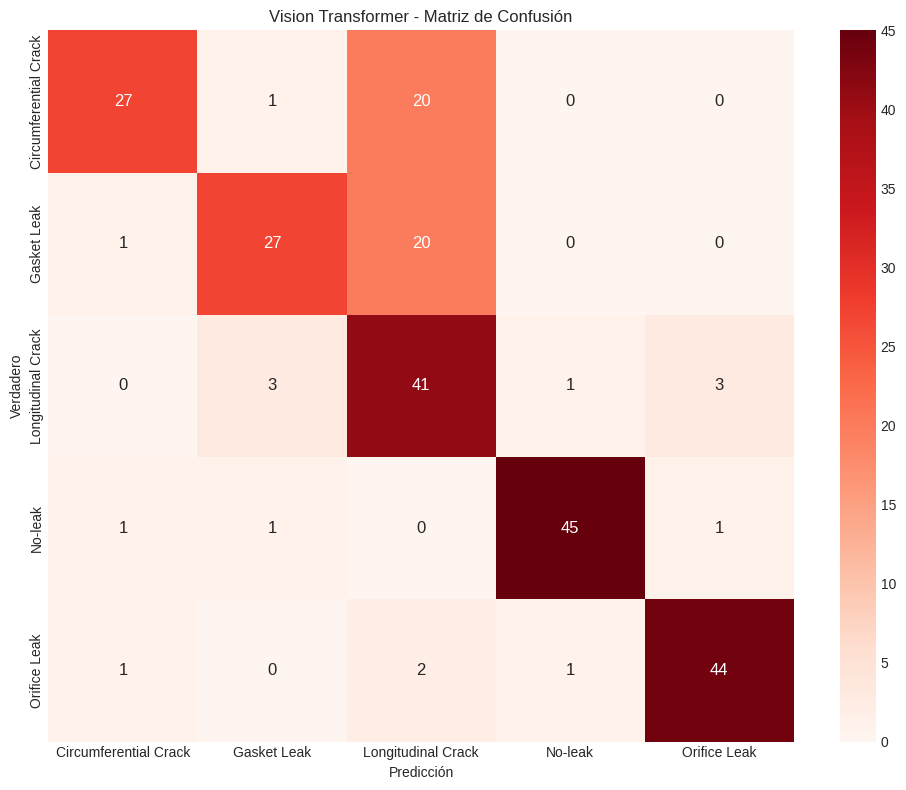

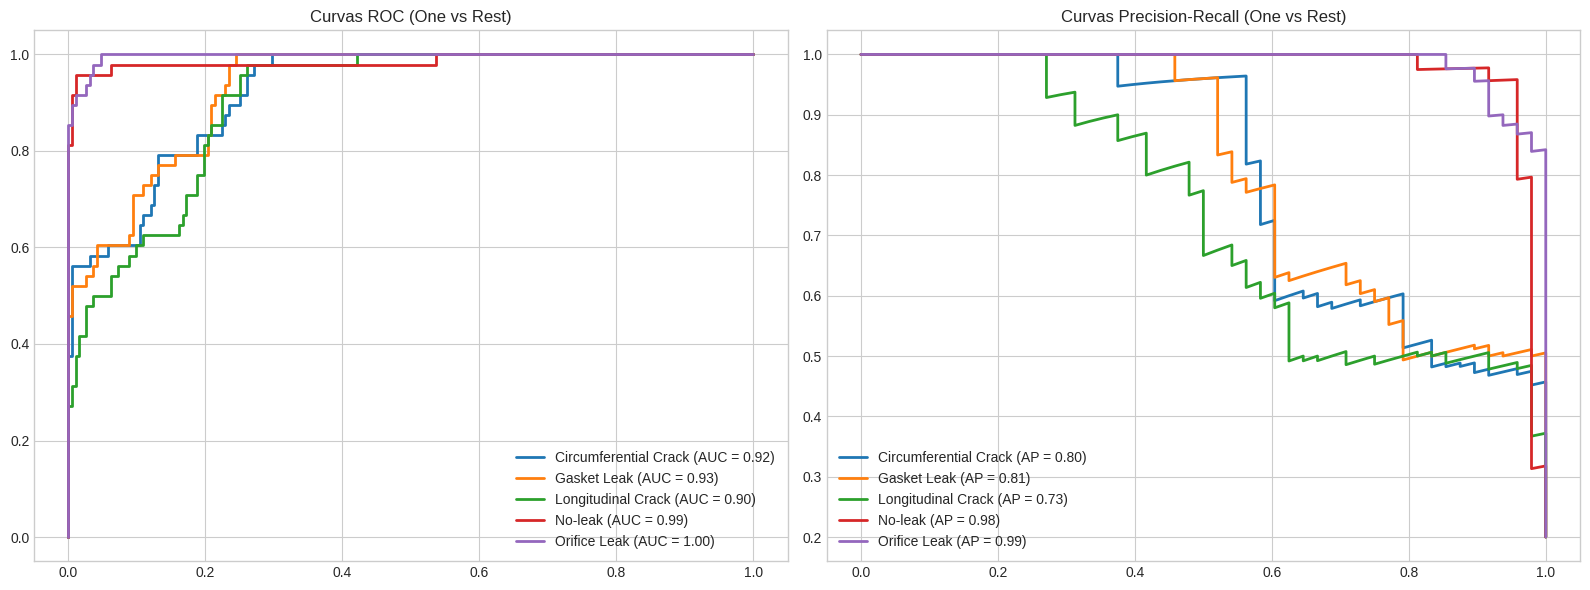


==== INFORME DETALLADO DE EVALUACIÓN ====

Modelo: Vision Transformer
- Exactitud: 0.7667
- Tiempo de inferencia total: 5.7524 segundos
- Tiempo por muestra: 23.9684 ms

Reporte de clasificación por clase:
- Circumferential Crack: Precisión=0.9000, Recall=0.5625, F1=0.6923
- Gasket Leak: Precisión=0.8438, Recall=0.5625, F1=0.6750
- Longitudinal Crack: Precisión=0.4940, Recall=0.8542, F1=0.6260
- No-leak: Precisión=0.9574, Recall=0.9375, F1=0.9474
- Orifice Leak: Precisión=0.9167, Recall=0.9167, F1=0.9167

Promedios ponderados:
- Precisión: 0.8224
- Recall: 0.7667
- F1-Score: 0.7715

Proceso de entrenamiento y evaluación del Vision Transformer completado.

Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
import torch.nn.init as init
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ==============================================================================
# ⚠️ CONFIGURACIÓN INICIAL (AJUSTAR AQUÍ) ⚠️
# ==============================================================================
# NOTA: Asegúrate de que estas variables estén definidas en celdas anteriores.

# --- Variables de Ejemplo (Ajusta esto si 'dataset_info' falla) ---
try:
    train_loader = dataset_info['train_loader']
    val_loader = dataset_info['val_loader']
    test_loader = dataset_info['test_loader']
    NUM_CLASSES = dataset_info['num_classes']
    IS_BINARY = (NUM_CLASSES == 2)
    INPUT_SHAPE = (3, 50, 2048)  # C x H x W (Ajusta si es diferente)
    classification_mode = 'binary' if IS_BINARY else f'{NUM_CLASSES}_classes'
    # Asegúrate de que label_codes_dict sea un mapeo {código_numérico: nombre_clase}
    label_codes_dict = dataset_info.get('label_codes_dict', {i: f'Clase {i}' for i in range(NUM_CLASSES)})
except NameError:
    # Este bloque solo se ejecutará si 'dataset_info' no existe.
    # DEBES DEFINIR TUS DATALOADERS Y PARAMETROS AQUI SI FALLA.
    print("Error: Las variables 'dataset_info' no están definidas.")
    raise

# ----------------------------------------------------------------------------------
# CLASE DEL MODELO (DESCONGELAMIENTO TOTAL)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        # Se usa el ViT base de timm
        self.vit = vit_base_patch16_224(pretrained=True)
        self.embed_dim = self.vit.embed_dim # 768

        # 1. Adaptar Patch Embedding
        # Puedes probar kernel_size=(4, 64) o (8, 32) si (16, 16) no funciona
        self.patch_embed = nn.Conv2d(
            in_channels=input_shape[0], out_channels=self.embed_dim, kernel_size=(16, 16), stride=(16, 16), padding='valid'
        )

        # 2. Recalcular y Reconstruir Positional Embedding
        H, W = input_shape[1], input_shape[2]
        num_patches_h = (H - 16) // 16 + 1
        num_patches_w = (W - 16) // 16 + 1
        num_patches_new = num_patches_h * num_patches_w

        self.cls_token = nn.Parameter(self.vit.cls_token.data.clone())
        new_pos_embed = nn.Parameter(torch.zeros(1, num_patches_new + 1, self.embed_dim))
        init.trunc_normal_(new_pos_embed, std=.02)
        self.pos_embed = new_pos_embed

        # 3. Adaptar Classification Head
        in_features = self.vit.head.in_features
        # ⭐️ REGULARIZACIÓN: Dropout fuerte
        self.dropout = nn.Dropout(p=0.4)
        if self.is_binary:
            self.head = nn.Linear(in_features, 1)
        else:
            self.head = nn.Linear(in_features, num_classes)

        # 4. Asignaciones y Correcciones de Atributos
        self.vit.patch_embed = self.patch_embed
        self.vit.cls_token = self.cls_token
        self.vit.pos_embed = self.pos_embed
        self.vit.head = self.head

        if not hasattr(self.vit, 'pre_logits'):
            self.vit.pre_logits = nn.Identity()

        # 5. 💥 MEJORA AGRESIVA: DESCONGELAR TODO
        # Esto aumenta la capacidad del modelo para adaptarse a los escalogramas
        # pero requiere un LR MUCHO más bajo.
        for param in self.vit.parameters():
            param.requires_grad = True # <--- ¡CAMBIO CLAVE!

    def forward(self, x):
        # Implementación manual del forward
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        x = self.vit.pre_logits(x[:, 0])
        # Aplicar el dropout
        x = self.dropout(x)
        x = self.vit.head(x)

        if self.is_binary:
            return x.squeeze(1) # Devolver logits
        else:
            return x

# ----------------------------------------------------------------------------------
# CONFIGURACIÓN, ENTRENAMIENTO Y EVALUACIÓN
# ----------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
epochs = 100
early_stop_patience = 30 # Aumentado para early stopping
model_save_path = f'/content/drive/MyDrive/CWT modelo preentrenado/Looped/vit_cwt_looped_{classification_mode}_aggressive.pt'

model = LogPSViT(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, is_binary=IS_BINARY)
model.to(device)

# Ajuste de la función de pérdida para que coincida con la salida del forward (logits/salidas sin softmax)
# El forward para binario ahora devuelve logits, no sigmoide.
criterion = nn.BCEWithLogitsLoss() if IS_BINARY else nn.CrossEntropyLoss()
learning_rate = 1e-5 # 💥 LR MUCHO MÁS BAJO para descongelamiento total

# 💥 REGULARIZACIÓN L2: weight_decay alto ya que hay muchos más parámetros activos
optimizer = torch.optim.AdamW(model.parameters(),
                             lr=learning_rate,
                             weight_decay=0.05)

# Ajustamos la paciencia para que sea más tolerante a LR bajos
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-7)

# Normalización estándar de ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# ⭐️ DATA AUGMENTATION: Crea una transformación simple
transform_data_aug = transforms.RandomHorizontalFlip(p=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []}
best_val_loss = float('inf')
epochs_no_improve = 0


print("\nComenzando el entrenamiento AGRESIVO del modelo Vision Transformer...")

# --- BUCLE PRINCIPAL DE ENTRENAMIENTO ---
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss, train_correct_preds, train_total_samples = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        # ⭐️ Aplicar Aumento de Datos solo en TRAIN
        inputs = transform_data_aug(inputs)

        inputs = normalize(inputs)

        # Modificación para BCEWithLogitsLoss: la etiqueta debe ser float
        if IS_BINARY: labels_for_loss = labels.float().unsqueeze(1)
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs) # Outputs son logits (binario) o logit scores (multiclase)
        loss = criterion(outputs, labels_for_loss)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        if IS_BINARY:
            # Para la precisión, aplicamos sigmoide y luego umbral
            preds = (torch.sigmoid(outputs).squeeze(1) > 0.5).long()
        else:
            _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # --- BUCLE DE VALIDACIÓN ---
    model.eval()
    val_loss, val_correct_preds, val_total_samples = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            # No aplicar Data Augmentation en Validación
            inputs = normalize(inputs)

            if IS_BINARY: labels_for_loss = labels.float().unsqueeze(1)
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if IS_BINARY:
                preds = (torch.sigmoid(outputs).squeeze(1) > 0.5).long()
            else:
                _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | LR: {optimizer.param_groups[0]['lr']:.8f} | Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
# 4. EVALUACIÓN Y CÁLCULO DE MÉTRICAS (Añadimos medición de tiempo)
# ----------------------------------------------------------------------------------

print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

y_pred_prob_list = []
y_test_true_list = []
total_test_samples = 0
correct_predictions = 0

start_time = time.time() # ⭐️ INICIO DEL TIEMPO DE INFERENCIA
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)
        outputs = model(inputs) # Estos son logits (binario) o logit scores (multiclase)

        if IS_BINARY:
            probs = torch.sigmoid(outputs).squeeze(1)
            y_pred_prob_list.extend(probs.cpu().numpy().flatten())
            y_test_true_list.extend(labels.cpu().numpy().flatten())

            preds = (probs > 0.5).long()
        else:
            probs = F.softmax(outputs, dim=1)
            y_pred_prob_list.extend(probs.cpu().numpy())
            y_test_true_list.extend(labels.cpu().numpy())

            _, preds = torch.max(outputs, 1)

        correct_predictions += (preds == labels).sum().item()
        total_test_samples += labels.size(0)

inference_time = time.time() - start_time # ⭐️ FIN DEL TIEMPO DE INFERENCIA

# Conversión a NumPy
y_pred_prob = np.array(y_pred_prob_list)
y_test_true = np.array(y_test_true_list)
accuracy = correct_predictions / total_test_samples

# --- DETERMINAR NOMBRES DE CLASES Y PREDICCIONES FINALES ---
code_to_name = {v: k for k, v in label_codes_dict.items()}
class_names = [code_to_name[i] for i in range(NUM_CLASSES)]

if IS_BINARY:
    y_pred = (y_pred_prob > 0.5).astype(int)
else:
    y_pred = np.argmax(y_pred_prob, axis=1)

# Ajuste de la forma de las probabilidades para el caso multiclase si es necesario
if not IS_BINARY:
    y_pred_probs_np = y_pred_prob.reshape(-1, NUM_CLASSES)
else:
    y_pred_probs_np = y_pred_prob


# --- REPORTE DE CLASIFICACIÓN ---
print("\nGenerando métricas de evaluación detalladas...")
reporte_clasificacion = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)

# ⭐️ CREACIÓN DEL DICCIONARIO DE RESULTADOS PARA EL PUNTO 6 Y VISUALIZACIÓN
resultados_vit = {
    'model_name': "Vision Transformer",
    'accuracy': accuracy,
    'confusion_matrix': confusion_matrix(y_test_true, y_pred),
    'classification_report': reporte_clasificacion,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / total_test_samples,
    'y_pred': y_pred,
    'y_true': y_test_true,
    'y_pred_probs': y_pred_probs_np
}

# ----------------------------------------------------------------------------------
# 5. VISUALIZACIÓN DEL RENDIMIENTO (Matriz de Confusión y Gráficos)
# ----------------------------------------------------------------------------------

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = resultados_vit['confusion_matrix']
plt.figure(figsize=(10, 8))
annot_settings = {'fontsize': 12}
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names, annot_kws=annot_settings)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Gráficos de rendimiento (ROC y PR)
if IS_BINARY:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], resultados_vit['y_pred_probs'])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], resultados_vit['y_pred_probs'])
    ap = average_precision_score(resultados_vit['y_true'], resultados_vit['y_pred_probs'])
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(resultados_vit['y_true']), num_classes=NUM_CLASSES).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], resultados_vit['y_pred_probs'][:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------------------------------
# 6. IMPRIMIR MÉTRICAS DETALLADAS (Implementación exacta del requerimiento)
# ----------------------------------------------------------------------------------

print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
# Convertir a ms para una mejor visualización de tiempo por muestra
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit['classification_report']:
        cls_metrics = resultados_vit['classification_report'][cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit['classification_report']:
    weighted_avg = resultados_vit['classification_report']['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

## Entrenamiento para mejorar el overfitting

Usando dispositivo: cuda

Comenzando el entrenamiento AGRESIVO del modelo Vision Transformer...


Epoch 1 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.24it/s]


Epoch 1/100: Train Loss: 1.6705, Train Acc: 0.3398 | Val Loss: 1.1643, Val Acc: 0.4635 | LR: 0.00001000 | Tiempo: 58.44s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_aggressive.pt (Val Loss: 1.1643)


Epoch 2 (Val): 100%|██████████| 6/6 [00:04<00:00,  1.21it/s]


Epoch 2/100: Train Loss: 1.1921, Train Acc: 0.4922 | Val Loss: 1.0111, Val Acc: 0.5625 | LR: 0.00001000 | Tiempo: 57.85s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_aggressive.pt (Val Loss: 1.0111)


...

Epoch 51/100: Train Loss: 0.0004, Train Acc: 1.0000 | Val Loss: 0.6438, Val Acc: 0.8750 | LR: 0.00000500 | Tiempo: 57.33s


Epoch 52 (Val): 100%|██████████| 6/6 [00:05<00:00,  1.18it/s]


Epoch 52/100: Train Loss: 0.0005, Train Acc: 1.0000 | Val Loss: 0.6335, Val Acc: 0.8750 | LR: 0.00000500 | Tiempo: 57.35s
Early stopping activado después de 30 épocas sin mejora.

Entrenamiento finalizado.

Evaluando el modelo Vision Transformer en el conjunto de prueba...


Evaluando en test: 100%|██████████| 8/8 [00:06<00:00,  1.33it/s]



Generando métricas de evaluación detalladas...

Reporte de clasificación por clase:
- Circumferential Crack: Precisión=0.9020, Recall=0.9583, F1=0.9293
- Gasket Leak: Precisión=0.7241, Recall=0.8750, F1=0.7925
- Longitudinal Crack: Precisión=0.8571, Recall=0.8750, F1=0.8660
- No-leak: Precisión=0.7778, Recall=0.7292, F1=0.7527
- Orifice Leak: Precisión=0.8649, Recall=0.6667, F1=0.7529

Promedios ponderados:
- Precisión: 0.8252
- Recall: 0.8208
- F1-Score: 0.8187

Generando matriz de confusión...


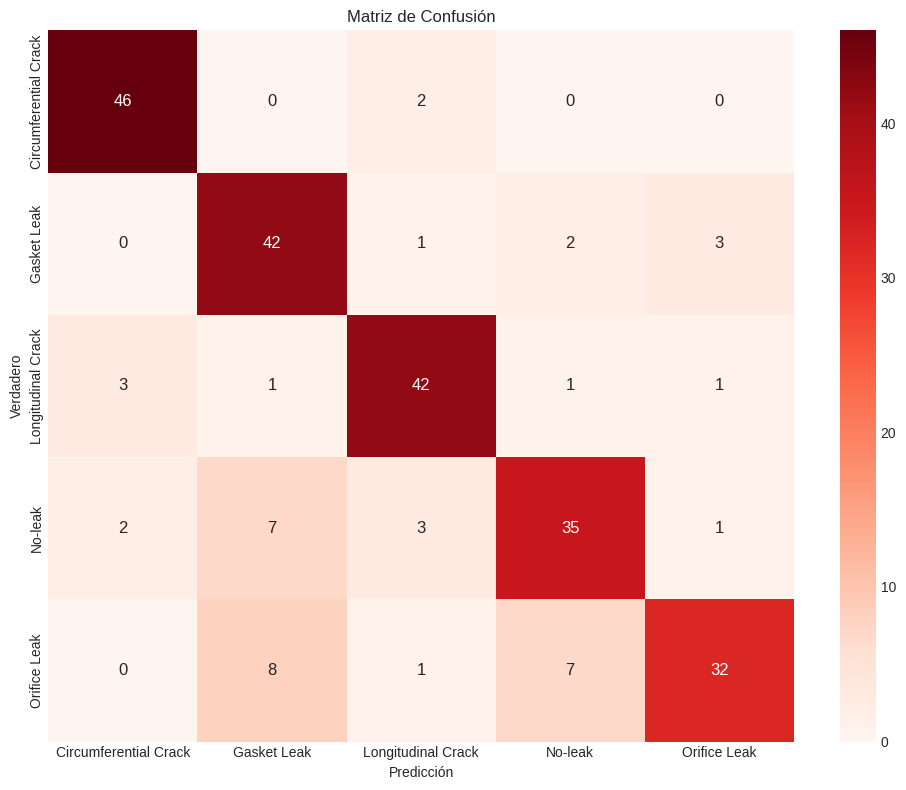

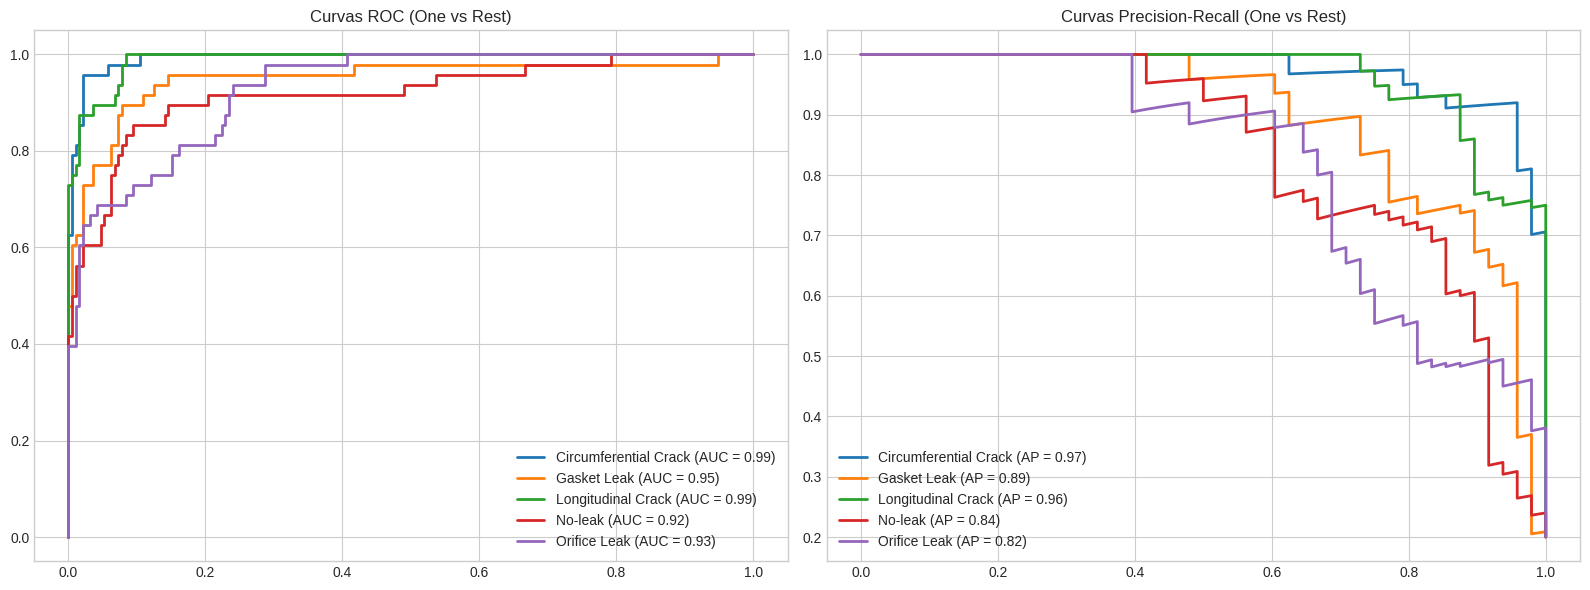


Proceso de entrenamiento y evaluación del Vision Transformer completado.


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
import torch.nn.init as init
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ==============================================================================
#                      ⚠️ CONFIGURACIÓN INICIAL (AJUSTAR AQUÍ) ⚠️
# ==============================================================================
# NOTA: Asegúrate de que estas variables estén definidas en celdas anteriores.

# --- Variables de Ejemplo (Ajusta esto si 'dataset_info' falla) ---
try:
    train_loader = dataset_info['train_loader']
    val_loader = dataset_info['val_loader']
    test_loader = dataset_info['test_loader']
    NUM_CLASSES = dataset_info['num_classes']
    IS_BINARY = (NUM_CLASSES == 2)
    INPUT_SHAPE = (3, 50, 2048)  # C x H x W (Ajusta si es diferente)
    classification_mode = 'binary' if IS_BINARY else f'{NUM_CLASSES}_classes'
    # Asegúrate de que label_codes_dict sea un mapeo {código_numérico: nombre_clase}
    label_codes_dict = dataset_info.get('label_codes_dict', {i: f'Clase {i}' for i in range(NUM_CLASSES)})
except NameError:
    # Este bloque solo se ejecutará si 'dataset_info' no existe.
    # DEBES DEFINIR TUS DATALOADERS Y PARAMETROS AQUI SI FALLA.
    print("Error: Las variables 'dataset_info' no están definidas.")
    raise

# ----------------------------------------------------------------------------------
#  CLASE DEL MODELO (DESCONGELAMIENTO TOTAL)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        # Se usa el ViT base de timm
        self.vit = vit_base_patch16_224(pretrained=True)
        self.embed_dim = self.vit.embed_dim # 768

        # 1. Adaptar Patch Embedding
        # Puedes probar kernel_size=(4, 64) o (8, 32) si (16, 16) no funciona
        self.patch_embed = nn.Conv2d(
            in_channels=input_shape[0], out_channels=self.embed_dim, kernel_size=(16, 16), stride=(16, 16), padding='valid'
        )

        # 2. Recalcular y Reconstruir Positional Embedding
        H, W = input_shape[1], input_shape[2]
        num_patches_h = (H - 16) // 16 + 1
        num_patches_w = (W - 16) // 16 + 1
        num_patches_new = num_patches_h * num_patches_w

        self.cls_token = nn.Parameter(self.vit.cls_token.data.clone())
        new_pos_embed = nn.Parameter(torch.zeros(1, num_patches_new + 1, self.embed_dim))
        init.trunc_normal_(new_pos_embed, std=.02)
        self.pos_embed = new_pos_embed

        # 3. Adaptar Classification Head
        in_features = self.vit.head.in_features
        # ⭐️ REGULARIZACIÓN: Dropout fuerte
        self.dropout = nn.Dropout(p=0.4)
        if self.is_binary:
            self.head = nn.Linear(in_features, 1)
        else:
            self.head = nn.Linear(in_features, num_classes)

        # 4. Asignaciones y Correcciones de Atributos
        self.vit.patch_embed = self.patch_embed
        self.vit.cls_token = self.cls_token
        self.vit.pos_embed = self.pos_embed
        self.vit.head = self.head

        if not hasattr(self.vit, 'pre_logits'):
             self.vit.pre_logits = nn.Identity()

        # 5. 💥 MEJORA AGRESIVA: DESCONGELAR TODO
        # Esto aumenta la capacidad del modelo para adaptarse a los escalogramas
        # pero requiere un LR MUCHO más bajo.
        for param in self.vit.parameters():
            param.requires_grad = True # <--- ¡CAMBIO CLAVE!

    def forward(self, x):
        # Implementación manual del forward
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        x = self.vit.pre_logits(x[:, 0])
        # Aplicar el dropout
        x = self.dropout(x)
        x = self.vit.head(x)

        if self.is_binary:
            return torch.sigmoid(x).squeeze(1)
        else:
            return x

# ----------------------------------------------------------------------------------
#  CONFIGURACIÓN, ENTRENAMIENTO Y EVALUACIÓN
# ----------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
epochs = 100
early_stop_patience = 30 # Aumentado para early stopping
model_save_path = f'/content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_{classification_mode}_aggressive.pt'

model = LogPSViT(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, is_binary=IS_BINARY)
model.to(device)

criterion = nn.BCELoss() if IS_BINARY else nn.CrossEntropyLoss()
learning_rate = 1e-5 # 💥 LR MUCHO MÁS BAJO para descongelamiento total

# 💥 REGULARIZACIÓN L2: weight_decay alto ya que hay muchos más parámetros activos
optimizer = torch.optim.AdamW(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=0.05)

# Ajustamos la paciencia para que sea más tolerante a LR bajos
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-7)

# Normalización estándar de ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# ⭐️ DATA AUGMENTATION: Crea una transformación simple
transform_data_aug = transforms.RandomHorizontalFlip(p=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []}
best_val_loss = float('inf')
epochs_no_improve = 0


print("\nComenzando el entrenamiento AGRESIVO del modelo Vision Transformer...")

# --- BUCLE PRINCIPAL DE ENTRENAMIENTO ---
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss, train_correct_preds, train_total_samples = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        # ⭐️ Aplicar Aumento de Datos solo en TRAIN
        inputs = transform_data_aug(inputs)

        inputs = normalize(inputs)

        if IS_BINARY: labels_for_loss = labels.float()
        else: labels_for_loss = labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        if IS_BINARY: preds = (outputs > 0.5)
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # --- BUCLE DE VALIDACIÓN ---
    model.eval()
    val_loss, val_correct_preds, val_total_samples = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            # No aplicar Data Augmentation en Validación
            inputs = normalize(inputs)

            if IS_BINARY: labels_for_loss = labels.float()
            else: labels_for_loss = labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if IS_BINARY: preds = (outputs > 0.5)
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | LR: {optimizer.param_groups[0]['lr']:.8f} | Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
#  EVALUACIÓN Y VISUALIZACIÓN DEL RENDIMIENTO
# ----------------------------------------------------------------------------------

print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)
        outputs = model(inputs)

        if IS_BINARY:
            y_pred_prob.extend(outputs.cpu().numpy().flatten())
            y_test_true.extend(labels.cpu().numpy().flatten())
        else:
            y_pred_prob.extend(outputs.cpu().numpy())
            y_test_true.extend(labels.cpu().numpy())


y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

# --- DETERMINAR NOMBRES DE CLASES ---
code_to_name = {v: k for k, v in label_codes_dict.items()}

if IS_BINARY:
    y_pred = (y_pred_prob > 0.5).astype(int)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]
    y_test_flat = y_test_true
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]

# --- REPORTE DE CLASIFICACIÓN ---
print("\nGenerando métricas de evaluación detalladas...")
resultados_vit = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit:
        cls_metrics = resultados_vit[cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit:
    weighted_avg = resultados_vit['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
annot_settings = {'fontsize': 12}
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_settings)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Gráficos de rendimiento (ROC y PR)
if IS_BINARY:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_prob)
    ap = average_precision_score(y_test_flat, y_pred_prob)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=NUM_CLASSES).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score = y_pred_prob[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

In [19]:
# 6. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")



==== INFORME DETALLADO DE EVALUACIÓN ====

- Exactitud: 0.7542


## Otro intento

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import os
import time
from tqdm import tqdm
from torchvision import transforms
from timm.models.vision_transformer import vit_base_patch16_224
import torch.nn.init as init
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F
import gc

# ==============================================================================
#                      ⚠️ CONFIGURACIÓN INICIAL (AJUSTAR AQUÍ) ⚠️
# ==============================================================================
# NOTA: Asegúrate de que estas variables estén definidas en celdas anteriores.

# --- Variables Requeridas ---
# Si usas Colab, estas variables deben ser definidas ANTES de este bloque de código.
# Ejemplo ASUMIDO (si fallan, DEBES haberlas definido previamente):
try:
    train_loader = dataset_info['train_loader']
    val_loader = dataset_info['val_loader']
    test_loader = dataset_info['test_loader']
    NUM_CLASSES = dataset_info['num_classes']
    IS_BINARY = (NUM_CLASSES == 2)
    # 💥 AJUSTA ESTO a las dimensiones reales de tus escalogramas C x H x W
    INPUT_SHAPE = (3, 50, 2048)
    classification_mode = 'binary' if IS_BINARY else f'{NUM_CLASSES}_classes'
    label_codes_dict = dataset_info.get('label_codes_dict', {i: f'Clase {i}' for i in range(NUM_CLASSES)})
except NameError:
    print("FATAL ERROR: Las variables 'dataset_info' (DataLoaders, clases, shape) NO están definidas.")
    print("Asegúrate de ejecutar la celda donde se cargan y preparan los datos.")
    raise

# ----------------------------------------------------------------------------------
#  CLASE DEL MODELO (ViT BASE CON PARCHE ADAPTADO)
# ----------------------------------------------------------------------------------
class LogPSViT(nn.Module):
    def __init__(self, input_shape, num_classes, is_binary=True):
        super(LogPSViT, self).__init__()
        self.is_binary = is_binary
        self.vit = vit_base_patch16_224(pretrained=True)
        self.embed_dim = self.vit.embed_dim # 768

        # 💥 ADAPTACIÓN CRÍTICA DEL PARCHE: (8, 32)
        PATCH_SIZE_H = 8
        PATCH_SIZE_W = 32
        self.patch_embed = nn.Conv2d(
            in_channels=input_shape[0], out_channels=self.embed_dim,
            kernel_size=(PATCH_SIZE_H, PATCH_SIZE_W), stride=(PATCH_SIZE_H, PATCH_SIZE_W), padding='valid'
        )

        # 2. Recalcular y Reconstruir Positional Embedding
        H, W = input_shape[1], input_shape[2]
        # Cálculo de parches ajustado
        num_patches_h = (H - PATCH_SIZE_H) // PATCH_SIZE_H + 1
        num_patches_w = (W - PATCH_SIZE_W) // PATCH_SIZE_W + 1
        num_patches_new = num_patches_h * num_patches_w

        self.cls_token = nn.Parameter(self.vit.cls_token.data.clone())
        new_pos_embed = nn.Parameter(torch.zeros(1, num_patches_new + 1, self.embed_dim))
        init.trunc_normal_(new_pos_embed, std=.02)
        self.pos_embed = new_pos_embed

        # 3. Adaptar Classification Head
        in_features = self.vit.head.in_features
        # Dropout (p=0.4) para regularización
        self.dropout = nn.Dropout(p=0.4)
        if self.is_binary:
            self.head = nn.Linear(in_features, 1)
        else:
            self.head = nn.Linear(in_features, num_classes)

        # 4. Asignaciones y Descongelamiento Total
        self.vit.patch_embed = self.patch_embed
        self.vit.cls_token = self.cls_token
        self.vit.pos_embed = self.pos_embed
        self.vit.head = self.head
        if not hasattr(self.vit, 'pre_logits'):
             self.vit.pre_logits = nn.Identity()

        # Descongelamiento total: control del overfitting con LR y L2
        for param in self.vit.parameters():
            param.requires_grad = True

    def forward(self, x):
        # Forward Pass adaptado
        x = self.vit.patch_embed(x)
        x = x.flatten(2).transpose(1, 2)
        cls_token = self.vit.cls_token.expand(x.shape[0], -1, -1)
        x = torch.cat((cls_token, x), dim=1)
        x = x + self.vit.pos_embed
        x = self.vit.pos_drop(x)
        x = self.vit.blocks(x)
        x = self.vit.norm(x)
        x = self.vit.pre_logits(x[:, 0])
        x = self.dropout(x)
        x = self.vit.head(x)

        if self.is_binary:
            return torch.sigmoid(x).squeeze(1)
        else:
            return x

# ----------------------------------------------------------------------------------
#  CONFIGURACIÓN, ENTRENAMIENTO Y EVALUACIÓN
# ----------------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 100
early_stop_patience = 30
model_save_path = f'/content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_{classification_mode}_base_mitigado.pt'

model = LogPSViT(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES, is_binary=IS_BINARY)
model.to(device)

criterion = nn.BCELoss() if IS_BINARY else nn.CrossEntropyLoss()
# ⭐️ LR BAJO para aprendizaje lento y suave
learning_rate = 1e-5

# ⭐️ Weight Decay MODERADO
optimizer = torch.optim.AdamW(model.parameters(),
                                 lr=learning_rate,
                                 weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-7)

# Normalización estándar de ImageNet
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 💥 Aumento de Datos INTEGRAL
transform_data_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05), shear=5, fill=0),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.05),
])

history = {'train_loss': [], 'val_loss': [], 'train_accuracy': [], 'val_accuracy': [], 'lr': []}
best_val_loss = float('inf')
epochs_no_improve = 0


print(f"Usando dispositivo: {device}")
print("\n🚀 Comenzando el entrenamiento (ViT BASE con Regularización Suave)...")

# --- BUCLE PRINCIPAL DE ENTRENAMIENTO ---
for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss, train_correct_preds, train_total_samples = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Aplicar Aumento de Datos y Normalización
        inputs = transform_data_aug(inputs)
        inputs = normalize(inputs)

        labels_for_loss = labels.float() if IS_BINARY else labels

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels_for_loss)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)

        if IS_BINARY: preds = (outputs > 0.5)
        else: _, preds = torch.max(outputs, 1)

        train_correct_preds += (preds == labels).sum().item()
        train_total_samples += labels.size(0)

    epoch_train_loss = train_loss / train_total_samples
    epoch_train_accuracy = train_correct_preds / train_total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # --- BUCLE DE VALIDACIÓN ---
    model.eval()
    val_loss, val_correct_preds, val_total_samples = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)
            inputs = normalize(inputs)

            labels_for_loss = labels.float() if IS_BINARY else labels

            outputs = model(inputs)
            loss = criterion(outputs, labels_for_loss)
            val_loss += loss.item() * inputs.size(0)

            if IS_BINARY: preds = (outputs > 0.5)
            else: _, preds = torch.max(outputs, 1)

            val_correct_preds += (preds == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_loss / val_total_samples
    epoch_val_accuracy = val_correct_preds / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    epoch_duration = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs}: Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | LR: {optimizer.param_groups[0]['lr']:.8f} | Tiempo: {epoch_duration:.2f}s")

    scheduler.step(epoch_val_loss)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), model_save_path)
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping activado después de {early_stop_patience} épocas sin mejora.")
            break

    gc.collect()

print("\nEntrenamiento finalizado.")

# ----------------------------------------------------------------------------------
# 📊 VISUALIZACIÓN DE LA HISTORIA DEL ENTRENAMIENTO
# ----------------------------------------------------------------------------------

plt.figure(figsize=(16, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='red')
plt.title('Pérdida (Loss) a lo largo de las Épocas')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Train Accuracy', color='blue')
plt.plot(history['val_accuracy'], label='Val Accuracy', color='red')
plt.title('Precisión (Accuracy) a lo largo de las Épocas')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------------------------------
# 🔬 EVALUACIÓN Y VISUALIZACIÓN DE MÉTRICAS FINALES
# ----------------------------------------------------------------------------------

print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

y_pred_prob = []
y_test_true = []
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)
        inputs = normalize(inputs)
        outputs = model(inputs)

        if IS_BINARY:
            y_pred_prob.extend(outputs.cpu().numpy().flatten())
            y_test_true.extend(labels.cpu().numpy().flatten())
        else:
            y_pred_prob.extend(outputs.cpu().numpy())
            y_test_true.extend(labels.cpu().numpy())


y_pred_prob = np.array(y_pred_prob)
y_test_true = np.array(y_test_true)

# --- DETERMINAR NOMBRES DE CLASES ---
code_to_name = {v: k for k, v in label_codes_dict.items()}

if IS_BINARY:
    y_pred = (y_pred_prob > 0.5).astype(int)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]
    y_test_flat = y_test_true
else:
    y_pred = np.argmax(y_pred_prob, axis=1)
    class_names = [code_to_name[i] for i in range(NUM_CLASSES)]

# --- REPORTE DE CLASIFICACIÓN ---
print("\nGenerando métricas de evaluación detalladas...")
resultados_vit = classification_report(y_test_true, y_pred, target_names=class_names, output_dict=True)

print("\nReporte de clasificación por clase:")
for cls in class_names:
    if cls in resultados_vit:
        cls_metrics = resultados_vit[cls]
        print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
              f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

if 'weighted avg' in resultados_vit:
    weighted_avg = resultados_vit['weighted avg']
    print(f"\nPromedios ponderados:")
    print(f"- Precisión: {weighted_avg['precision']:.4f}")
    print(f"- Recall: {weighted_avg['recall']:.4f}")
    print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Matriz de confusión
print("\nGenerando matriz de confusión...")
cm = confusion_matrix(y_test_true, y_pred)
plt.figure(figsize=(10, 8))
annot_settings = {'fontsize': 12}
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names,annot_kws=annot_settings)
plt.title(f"Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Verdadero")
plt.tight_layout()
plt.show()

# Gráficos de rendimiento (ROC y PR)
if IS_BINARY:
    plt.figure(figsize=(16, 6))

    # Curva ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(y_test_flat, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Curva Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(y_test_flat, y_pred_prob)
    ap = average_precision_score(y_test_flat, y_pred_prob)
    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

else: # Multiclase
    plt.figure(figsize=(16, 6))

    # Curva ROC multiclase
    plt.subplot(1, 2, 1)
    y_test_onehot = F.one_hot(torch.tensor(y_test_true), num_classes=NUM_CLASSES).float().numpy()
    for i, cls_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_test_onehot[:, i], y_pred_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Curva Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (y_test_true == i).astype(int)
        y_score = y_pred_prob[:, i]
        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)
        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")
    plt.tight_layout()
    plt.show()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Usando dispositivo: cuda

🚀 Comenzando el entrenamiento (ViT BASE con Regularización Suave)...


Epoch 1 (Val): 100%|██████████| 6/6 [00:05<00:00,  1.19it/s]


Epoch 1/100: Train Loss: 1.9546, Train Acc: 0.2005 | Val Loss: 1.5662, Val Acc: 0.2031 | LR: 0.00001000 | Tiempo: 60.54s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_base_mitigado.pt (Val Loss: 1.5662)


Epoch 2 (Val): 100%|██████████| 6/6 [00:05<00:00,  1.16it/s]


Epoch 2/100: Train Loss: 1.5892, Train Acc: 0.2565 | Val Loss: 1.4909, Val Acc: 0.3229 | LR: 0.00001000 | Tiempo: 60.96s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_base_mitigado.pt (Val Loss: 1.4909)


Epoch 3 (Val): 100%|██████████| 6/6 [00:05<00:00,  1.18it/s]


Epoch 3/100: Train Loss: 1.5443, Train Acc: 0.3021 | Val Loss: 1.4855, Val Acc: 0.2656 | LR: 0.00001000 | Tiempo: 60.39s
Mejor modelo guardado en /content/drive/MyDrive/CWT modelo preentrenado/Branched/vit_cwt_5_classes_base_mitigado.pt (Val Loss: 1.4855)


Epoch 4 (Train):  38%|███▊      | 9/24 [00:21<00:34,  2.27s/it]

In [ ]:

from torch import nn
from torch.optim import Adam
import torch.nn.functional as F # For one_hot, if you choose to use it in loss.
import numpy as np # Still useful for initial data shaping/debugging

# --- 1. Helper Modules for Vision Transformer ---
# Estas clases (PatchEmbedding, Attention, MLP, Block) no se modifican,
# pero deben estar definidas en tu entorno antes de VisionTransformer.

class PatchEmbedding(nn.Module):
    """
    Splits the image into patches and then embeds them.
    """
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size[0] // patch_size[0]) * (img_size[1] // patch_size[1])
        self.patch_dim = in_channels * patch_size[0] * patch_size[1]

        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        # x shape: (batch_size, channels, H, W)
        x = self.proj(x) # (batch_size, embed_dim, H_new, W_new)
        x = x.flatten(2) # (batch_size, embed_dim, num_patches)
        x = x.transpose(1, 2) # (batch_size, num_patches, embed_dim)
        return x

class Attention(nn.Module):
    """
    Multi-Head Self-Attention (MSA) mechanism.
    """
    def __init__(self, dim, num_heads=8, qkv_bias=False, attn_drop=0., proj_drop=0.):
        super().__init__()
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

    def forward(self, x):
        B, N, C = x.shape # Batch_size, Num_patches (+cls_token), Embedding_dim
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]   # B, num_heads, N, head_dim

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x

class MLP(nn.Module):
    """
    Multi-Layer Perceptron (MLP) block for Transformer.
    """
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)

    def forward(self, x):
        x = self.fc1(x)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x

class Block(nn.Module):
    """
    Transformer Encoder Block.
    """
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, drop=0., attn_drop=0.,
                 act_layer=nn.GELU, norm_layer=nn.LayerNorm):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias, attn_drop=attn_drop, proj_drop=drop)
        self.norm2 = norm_layer(dim)
        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = MLP(in_features=dim, hidden_features=mlp_hidden_dim, act_layer=act_layer, drop=drop)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- 2. Vision Transformer Model ---

class VisionTransformer(nn.Module):
    def __init__(self, img_size=(50, 25600), patch_size=(10, 256), in_channels=1, num_classes=5,
                 embed_dim=768, depth=12, num_heads=12, mlp_ratio=4., qkv_bias=True, drop_rate=0.,
                 attn_drop_rate=0., norm_layer=nn.LayerNorm, is_binary=False):
        super().__init__()
        self.num_classes = num_classes
        self.is_binary = is_binary

        # Ensure image and patch sizes are tuples
        if isinstance(img_size, int):
            img_size = (img_size, img_size)
        if isinstance(patch_size, int):
            patch_size = (patch_size, patch_size)

        self.patch_embed = PatchEmbedding(
            img_size=img_size, patch_size=patch_size, in_channels=in_channels, embed_dim=embed_dim)
        num_patches = self.patch_embed.num_patches

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        self.pos_drop = nn.Dropout(p=drop_rate)

        self.blocks = nn.ModuleList([
            Block(
                dim=embed_dim, num_heads=num_heads, mlp_ratio=mlp_ratio, qkv_bias=qkv_bias,
                drop=drop_rate, attn_drop=attn_drop_rate, norm_layer=norm_layer
            )
            for _ in range(depth)
        ])
        self.norm = norm_layer(embed_dim)

        # --> CAMBIO 1: Ajustar la capa de salida para clasificación binaria <--
        # Si es clasificación binaria, la capa final debe tener 1 neurona
        # para que la salida sean logits únicos para cada muestra.
        # BCEWithLogitsLoss manejará la sigmoide internamente.
        if self.is_binary:
            self.head = nn.Linear(embed_dim, 1) # <--- CAMBIADO
        else:
            self.head = nn.Linear(embed_dim, num_classes) if num_classes > 0 else nn.Identity()


        # Initialize position embedding
        nn.init.trunc_normal_(self.pos_embed, std=.02)
        nn.init.trunc_normal_(self.cls_token, std=.02)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.trunc_normal_(m.weight, std=.02)
            if isinstance(m, nn.Linear) and m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)

    def forward_features(self, x):
        B = x.shape[0] # Batch size
        x = self.patch_embed(x) # (B, num_patches, embed_dim)

        cls_tokens = self.cls_token.expand(B, -1, -1)  # Expand (1, 1, embed_dim) to (B, 1, embed_dim)
        x = torch.cat((cls_tokens, x), dim=1) # (B, num_patches + 1, embed_dim)

        x = self.pos_drop(x + self.pos_embed)

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)
        # We take the output corresponding to the classification token
        return x[:, 0]

    def forward(self, x):
        x = self.forward_features(x)
        x = self.head(x)
        # --> CAMBIO 2: Eliminar la sigmoide aquí si se usa BCEWithLogitsLoss <--
        # La función de pérdida (BCEWithLogitsLoss) ya aplica la sigmoide internamente por estabilidad numérica.
        # Si la dejas aquí, la aplicarías dos veces.
        # if self.is_binary:
        #    return torch.sigmoid(x)  # <--- ELIMINAR/COMENTAR ESTA LÍNEA
        return x # Para clasificación multiclase, CrossEntropyLoss espera logits crudos


# --- 3. Model Instantiation and Setup for PyTorch ---

# Get input shape from the dataset (B, C, H, W) -> (C, H, W)
# dataset['x_train'] is already (Batch, Channels, Height, Width) from previous step
input_c = dataset['x_train'].shape[1]
input_h = dataset['x_train'].shape[2]
input_w = dataset['x_train'].shape[3]
input_shape_vit = (input_h, input_w) # ViT expects (H, W) for image_size

num_classes = len(dataset['label_codes_dict'])
is_binary = (classification_mode == 'binary')

# Define ViT parameters
# Estos son parámetros de ejemplo. AJUSTA ESTOS VALORES si sigues teniendo problemas de RAM
# o si quieres experimentar con modelos más grandes/pequeños.
# Los valores sugeridos para tu imagen grande son:
vit_patch_size_h = 25 # Parches más grandes -> menos parches -> menos memoria en atención
vit_patch_size_w = 512 # Parches más grandes
vit_embed_dim = 128 # Dimensión de embedding más pequeña
vit_depth = 4 # Menos bloques de Transformer
vit_num_heads = 4 # Menos cabezas de atención
vit_mlp_ratio = 4 # Ratio de MLP, generalmente 4 es estándar.


print(f"Input Scalogram Dimensions: {input_h}x{input_w} with {input_c} channel(s)")
print(f"ViT Patch Size: {vit_patch_size_h}x{vit_patch_size_w}")

# Instantiate the Vision Transformer model
print("Creando modelo Vision Transformer...")
vit_model = VisionTransformer(
    img_size=input_shape_vit,
    patch_size=(vit_patch_size_h, vit_patch_size_w),
    in_channels=input_c,
    num_classes=num_classes,
    embed_dim=vit_embed_dim,
    depth=vit_depth,
    num_heads=vit_num_heads,
    mlp_ratio=vit_mlp_ratio,
    is_binary=is_binary
)

# Move model to the detected device (GPU if available, else CPU)
# ASEGÚRATE DE QUE 'device' ESTÉ DEFINIDO ANTES DE ESTE BLOQUE
# Ejemplo: device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vit_model.to(device)

# Print model summary (simplified compared to Keras .summary())
print(vit_model)
print(f"Number of parameters: {sum(p.numel() for p in vit_model.parameters() if p.requires_grad)}")

# --> CAMBIO 3: Usar nn.BCEWithLogitsLoss para clasificación binaria <--
# Esta es la función de pérdida recomendada cuando el modelo devuelve logits.
if is_binary:
    criterion = nn.BCEWithLogitsLoss() # <--- CAMBIADO
else:
    # Para clasificación multiclase, CrossEntropyLoss espera logits crudos e índices de clase enteros
    criterion = nn.CrossEntropyLoss()

optimizer = Adam(vit_model.parameters(), lr=0.001)

# PyTorch doesn't have a direct `model.compile()` equivalent.
# Instead, you manually define the optimizer and loss function,
# and the training loop will handle the forward/backward passes.

print("Modelo Vision Transformer configurado con éxito.")

Input Scalogram Dimensions: 50x32768 with 1 channel(s)
ViT Patch Size: 25x512
Creando modelo Vision Transformer...
VisionTransformer(
  (patch_embed): PatchEmbedding(
    (proj): Conv2d(1, 128, kernel_size=(25, 512), stride=(25, 512))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=128, out_features=384, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=128, out_features=512, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=512, out_features=128, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (

In [ ]:

from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import gc
import time
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import os # For saving models
# tqdm es una buena práctica para ver el progreso, asegúrate de que esté importado
import tqdm


# --- Asegúrate de que 'device', 'vit_model', 'criterion', 'optimizer',
# --- 'num_classes', 'is_binary', y 'dataset' estén definidos previamente.
# --- Por ejemplo:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ... (definición de vit_model, criterion, optimizer, etc.)

# --- 1. Reduce el tamaño de lote (batch size) ---
batch_size = 32

# --- 2. Preparar PyTorch DataLoaders ---
print("Preparando PyTorch DataLoaders...")

# Use the appropriate labels for binary/multiclass
if is_binary:
    # PARA BCEWithLogitsLoss, las etiquetas deben ser FLOAT y tener la misma dimensión
    # que la salida del modelo (batch_size, 1). La unsqueeze(1) es para esto.
    train_labels = dataset['y_train'].float().unsqueeze(1)
    val_labels = dataset['y_val'].float().unsqueeze(1)
    test_labels = dataset['y_test'].float().unsqueeze(1)
else:
    # PARA CrossEntropyLoss, las etiquetas deben ser de tipo LONG (índices enteros de clase)
    # Si tus 'y_train_onehot' ya están como one-hot (ej. [0, 1]), CrossEntropyLoss
    # espera índices (ej. 1). Si ya son índices (ej. 0, 1, 2), no necesitas cambiar.
    # Dado que y_train_onehot probablemente es (batch_size, num_classes), necesitamos argmax.
    train_labels = torch.from_numpy(np.argmax(dataset['y_train_onehot'], axis=1)).long()
    val_labels = torch.from_numpy(np.argmax(dataset['y_val_onehot'], axis=1)).long()
    test_labels = torch.from_numpy(np.argmax(dataset['y_test_onehot'], axis=1)).long()

# Create TensorDatasets
train_dataset_pt = TensorDataset(dataset['x_train'], train_labels)
val_dataset_pt = TensorDataset(dataset['x_val'], val_labels)
test_dataset_pt = TensorDataset(dataset['x_test'], test_labels)

# Create DataLoaders
# shuffle=True for training data, False for validation/test
# drop_last=True for training to ensure all batches have the same size (useful for some optimizers/models)
train_loader = DataLoader(train_dataset_pt, batch_size=batch_size, shuffle=True, drop_last=True, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)
val_loader = DataLoader(val_dataset_pt, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)
test_loader = DataLoader(test_dataset_pt, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count() // 2 if os.cpu_count() else 0)

print(f"Número de batches de entrenamiento: {len(train_loader)}")
print(f"Número de batches de validación: {len(val_loader)}")
print(f"Número de batches de prueba: {len(test_loader)}")


# --- 3. Configurar callbacks (implementados en el bucle de entrenamiento) ---
epochs = 100
patience = 20 # EarlyStopping patience
best_val_loss = float('inf')
epochs_no_improve = 0
min_lr = 1e-7 # ReduceLROnPlateau min_lr

# Learning Rate Scheduler (ReduceLROnPlateau)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=7, min_lr=min_lr)

# Model Checkpoint path
model_save_path = "/content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth" # PyTorch models typically .pth or .pt


# --- 4. Bucle de Entrenamiento ---
print("\nEntrenando modelo Vision Transformer...")

# Store history for plotting later
history = {
    'train_loss': [],
    'train_accuracy': [],
    'val_loss': [],
    'val_accuracy': [],
    'lr': []
}

# Habilitar Mixed Precision Training si tu GPU lo soporta (muy recomendado para ahorrar RAM)
# Descomenta las siguientes dos líneas y las líneas `scaler.scale`, `scaler.step`, `scaler.update`
# Si no tienes GPU o tienes una GPU antigua, déjalas comentadas.
# from torch.cuda.amp import autocast, GradScaler
# scaler = GradScaler()


for epoch in range(epochs):
    vit_model.train() # Set model to training mode
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Training loop
    for inputs, labels in tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1} (Train)"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad() # Zero the gradients

        # --> CAMBIO 4: Envuelve el forward pass con autocast para mixed precision <--
        # Si habilitas Mixed Precision Training, descomenta la siguiente línea:
        # with autocast():
        outputs = vit_model(inputs)

        # La preparación de las etiquetas ahora se hace en la creación de DataLoader
        # Esto es más limpio y eficiente, así que ya no necesitas el bloque if/else aquí.
        # Las 'labels' ya deben tener la forma y tipo correctos.

        loss = criterion(outputs, labels)

        # --> CAMBIO 5: Lógica de Backward y Optimize para Mixed Precision <--
        # Si usas Mixed Precision Training, descomenta y usa el scaler:
        # scaler.scale(loss).backward()
        # scaler.step(optimizer)
        # scaler.update()
        # Si NO usas Mixed Precision, usa la lógica estándar:
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

        if is_binary:
            # Para clasificación binaria con BCEWithLogitsLoss, `outputs` son logits.
            # Aplica sigmoid para obtener probabilidades (0-1) y luego el umbral.
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct_predictions += (predicted == labels).sum().item() # `labels` ya es (B, 1) float
        else:
            # Para multi-clase: `outputs` son logits, obten la clase con el logit máximo.
            # `labels` ya son índices enteros (B,)
            _, predicted = torch.max(outputs.data, 1)
            correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)


    epoch_train_loss = running_loss / total_samples
    epoch_train_accuracy = correct_predictions / total_samples
    history['train_loss'].append(epoch_train_loss)
    history['train_accuracy'].append(epoch_train_accuracy)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Validation loop
    vit_model.eval() # Set model to evaluation mode
    val_running_loss = 0.0
    val_correct_predictions = 0
    val_total_samples = 0

    with torch.no_grad(): # Disable gradient calculations during validation
        for inputs, labels in tqdm.tqdm(val_loader, desc=f"Epoch {epoch+1} (Val)"):
            inputs, labels = inputs.to(device), labels.to(device)

            # --> CAMBIO 6: Envuelve el forward pass con autocast en validación <--
            # Si usas Mixed Precision Training, descomenta la siguiente línea:
            # with autocast():
            outputs = vit_model(inputs)

            # Las etiquetas ya están preparadas en el DataLoader.
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)

            if is_binary:
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                val_correct_predictions += (predicted == labels).sum().item()
            else:
                _, predicted = torch.max(outputs.data, 1)
                val_correct_predictions += (predicted == labels).sum().item()
            val_total_samples += labels.size(0)

    epoch_val_loss = val_running_loss / val_total_samples
    epoch_val_accuracy = val_correct_predictions / val_total_samples
    history['val_loss'].append(epoch_val_loss)
    history['val_accuracy'].append(epoch_val_accuracy)

    print(f"Epoch {epoch+1}/{epochs}: "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_accuracy:.4f} | "
          f"LR: {optimizer.param_groups[0]['lr']:.7f}")

    # Learning Rate Scheduler step
    scheduler.step(epoch_val_loss)

    # Early Stopping
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        epochs_no_improve = 0
        torch.save(vit_model.state_dict(), model_save_path) # Save best model
        print(f"Mejor modelo guardado en {model_save_path} (Val Loss: {best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == patience:
            print(f"Early stopping activado después de {patience} épocas sin mejora.")
            break

    gc.collect() # Clean memory at end of epoch


# --- 5. Evaluación del modelo en el conjunto de prueba ---
print("\nEvaluando el modelo Vision Transformer en el conjunto de prueba...")

# Load the best model weights before evaluation
vit_model.load_state_dict(torch.load(model_save_path))
vit_model.eval() # Set model to evaluation mode

test_running_loss = 0.0
test_correct_predictions = 0
test_total_samples = 0
all_y_true = []
all_y_pred_probs = []
all_y_pred = []

start_time = time.time()
with torch.no_grad():
    for inputs, labels in tqdm.tqdm(test_loader, desc="Evaluando en test"):
        inputs, labels = inputs.to(device), labels.to(device)

        # --> CAMBIO 7: Envuelve el forward pass con autocast en test <--
        # Si usas Mixed Precision Training, descomenta la siguiente línea:
        # with autocast():
        outputs = vit_model(inputs)

        # Las etiquetas ya están preparadas en el DataLoader.
        labels_for_loss = labels # Ya tienen el tipo y forma correctos

        loss = criterion(outputs, labels_for_loss) # Calculate loss with appropriate labels

        test_running_loss += loss.item() * inputs.size(0)

        # Store predictions and true labels
        if is_binary:
            y_prob_batch = torch.sigmoid(outputs) # Aplica sigmoid para obtener las probabilidades (0-1)
            y_pred_batch = (y_prob_batch > 0.5).float() # Predicciones binarias (0 o 1)

            # Para métricas de sklearn, las etiquetas verdaderas deben ser enteras (0 o 1)
            all_y_true.extend(labels.cpu().numpy().flatten()) # labels ya es (B, 1)
            all_y_pred.extend(y_pred_batch.cpu().numpy().flatten())
            all_y_pred_probs.extend(y_prob_batch.cpu().numpy().flatten())

            test_correct_predictions += (y_pred_batch == labels).sum().item() # Compara con labels (B, 1) float
        else:
            # Para multi-clase: `outputs` son logits, `labels` son índices enteros
            _, predicted_class = torch.max(outputs.data, 1) # Get predicted class from logits
            probs_batch = F.softmax(outputs, dim=1) # Convert logits to probabilities

            all_y_true.extend(labels.cpu().numpy()) # labels ya son índices enteros
            all_y_pred.extend(predicted_class.cpu().numpy())
            all_y_pred_probs.extend(probs_batch.cpu().numpy())

            test_correct_predictions += (predicted_class == labels).sum().item()
        test_total_samples += labels.size(0) # Usa labels.size(0) que es el batch_size

inference_time = time.time() - start_time

vit_test_loss = test_running_loss / test_total_samples
vit_test_acc = test_correct_predictions / test_total_samples

print(f"\nRendimiento del modelo Vision Transformer en conjunto de prueba:")
print(f"- Pérdida: {vit_test_loss:.4f}")
print(f"- Exactitud: {vit_test_acc:.4f}")

# Convert lists to numpy arrays for sklearn metrics
y_true_np = np.array(all_y_true)
y_pred_np = np.array(all_y_pred)
y_pred_probs_np = np.array(all_y_pred_probs)


# --- 6. Análisis detallado y Visualización ---
print("\nRealizando evaluación detallada del modelo Vision Transformer...")

# Calculate metrics
# accuracy = np.mean(y_pred_np == y_true_np) # Ya calculada como vit_test_acc
conf_matrix = confusion_matrix(y_true_np, y_pred_np)

# Get class names
class_names = list(dataset['label_codes_dict'].keys())

# Generate classification report
report = classification_report(y_true_np, y_pred_np, target_names=class_names, output_dict=True)

# Create results dictionary for visualization
resultados_vit = { # Renamed to avoid clash with original 'resultados'
    'model_name': "Vision Transformer",
    'accuracy': vit_test_acc, # Usa la exactitud calculada en PyTorch
    'confusion_matrix': conf_matrix,
    'classification_report': report,
    'inference_time': inference_time,
    'inference_time_per_sample': inference_time / len(y_true_np),
    'y_pred': y_pred_np,
    'y_true': y_true_np,
    'y_pred_probs': y_pred_probs_np
}

# 1. Matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(resultados_vit['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"{resultados_vit['model_name']} - Matriz de Confusión")
plt.ylabel("Verdadero")
plt.xlabel("Predicho")
plt.tight_layout()
plt.show()

# 2. Métricas por clase
plt.figure(figsize=(12, 6))
metrics = ['precision', 'recall', 'f1-score']
x = np.arange(len(class_names))
width = 0.25

for i, metric in enumerate(metrics):
    values = [resultados_vit['classification_report'][cls][metric] for cls in class_names]
    plt.bar(x + i*width - width, values, width, label=metric.capitalize())

plt.xlabel('Clase')
plt.ylabel('Valor')
plt.title('Métricas por Clase')
plt.xticks(x, class_names, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. ROC y Precision-Recall para clasificación multiclase/binaria
if len(class_names) > 2:  # Multiclase
    plt.figure(figsize=(16, 6))

    # ROC multiclase (one vs rest)
    plt.subplot(1, 2, 1)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        fpr, tpr, _ = roc_curve(y_true_binary, y_score)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curvas ROC (One vs Rest)')
    plt.legend(loc="lower right")

    # Precision-Recall multiclase
    plt.subplot(1, 2, 2)
    for i, cls_name in enumerate(class_names):
        y_true_binary = (resultados_vit['y_true'] == i).astype(int)
        y_score = resultados_vit['y_pred_probs'][:, i]

        precision, recall, _ = precision_recall_curve(y_true_binary, y_score)
        ap = average_precision_score(y_true_binary, y_score)

        plt.plot(recall, precision, lw=2, label=f'{cls_name} (AP = {ap:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curvas Precision-Recall (One vs Rest)')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

else:  # Binaria
    # Ensure y_pred_probs is 1D for binary metrics
    if resultados_vit['y_pred_probs'].ndim > 1: # Check if it's (N, 1)
        y_score = resultados_vit['y_pred_probs'].flatten()
    else: # If it's already (N,)
        y_score = resultados_vit['y_pred_probs']

    plt.figure(figsize=(16, 6))

    # ROC binaria
    plt.subplot(1, 2, 1)
    fpr, tpr, _ = roc_curve(resultados_vit['y_true'], y_score)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos')
    plt.ylabel('Tasa de Verdaderos Positivos')
    plt.title('Curva ROC')
    plt.legend(loc="lower right")

    # Precision-Recall binaria
    plt.subplot(1, 2, 2)
    precision, recall, _ = precision_recall_curve(resultados_vit['y_true'], y_score)
    ap = average_precision_score(resultados_vit['y_true'], y_score)

    plt.plot(recall, precision, lw=2, label=f'PR (AP = {ap:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Curva Precision-Recall')
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

# 4. Imprimir métricas detalladas
print("\n==== INFORME DETALLADO DE EVALUACIÓN ====\n")
print(f"Modelo: {resultados_vit['model_name']}")
print(f"- Exactitud: {resultados_vit['accuracy']:.4f}")
print(f"- Tiempo de inferencia total: {resultados_vit['inference_time']:.4f} segundos")
print(f"- Tiempo por muestra: {resultados_vit['inference_time_per_sample']*1000:.4f} ms")

print("\nReporte de clasificación por clase:")
for cls in class_names:
    cls_metrics = resultados_vit['classification_report'][cls]
    print(f"- {cls}: Precisión={cls_metrics['precision']:.4f}, "
          f"Recall={cls_metrics['recall']:.4f}, F1={cls_metrics['f1-score']:.4f}")

# Métricas globales (promedio ponderado)
weighted_avg = resultados_vit['classification_report']['weighted avg']
print(f"\nPromedios ponderados:")
print(f"- Precisión: {weighted_avg['precision']:.4f}")
print(f"- Recall: {weighted_avg['recall']:.4f}")
print(f"- F1-Score: {weighted_avg['f1-score']:.4f}")

# Save the model if it has good performance (uncomment and adjust threshold if needed)
# if vit_test_acc > 0.85: # Use vit_test_acc instead of generic 'accuracy'
#    print(f"\nModelo con buen rendimiento detectado. Guardando en {model_save_path}...")
#    torch.save(vit_model.state_dict(), model_save_path)

# Cleanup
del train_loader, val_loader, test_loader, train_dataset_pt, val_dataset_pt, test_dataset_pt
gc.collect()

print("\nProceso de entrenamiento y evaluación del Vision Transformer completado.")

Preparando PyTorch DataLoaders...
Número de batches de entrenamiento: 9
Número de batches de validación: 3
Número de batches de prueba: 3

Entrenando modelo Vision Transformer...


Epoch 1 (Val): 100%|██████████| 3/3 [00:00<00:00,  4.13it/s]


Epoch 1/100: Train Loss: 0.1475, Train Acc: 0.9618 | Val Loss: 0.1098, Val Acc: 0.9870 | LR: 0.0002500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.1098)


Epoch 2 (Val): 100%|██████████| 3/3 [00:00<00:00,  4.14it/s]


Epoch 2/100: Train Loss: 0.1179, Train Acc: 0.9757 | Val Loss: 0.1062, Val Acc: 0.9610 | LR: 0.0002500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.1062)


...

Epoch 92 (Val): 100%|██████████| 3/3 [00:00<00:00,  4.14it/s]


Epoch 92/100: Train Loss: 0.0014, Train Acc: 1.0000 | Val Loss: 0.0014, Val Acc: 1.0000 | LR: 0.0002500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.0014)


Epoch 93 (Val): 100%|██████████| 3/3 [00:00<00:00,  4.11it/s]


Epoch 93/100: Train Loss: 0.0013, Train Acc: 1.0000 | Val Loss: 0.0013, Val Acc: 1.0000 | LR: 0.0002500
Mejor modelo guardado en /content/drive/MyDrive/CWT/Looped/vit_scalograms_best_model.pth (Val Loss: 0.0013)


Epoch 94 (Train):  11%|█         | 1/9 [00:00<00:02,  2.74it/s]